In [32]:
import pandas as pd
df = pd.read_csv("mmm_to_usd.csv")

google_spend_cols = [col for col in df.columns if col.startswith("GOOGLE_") and col.endswith("_SPEND")]
meta_spend_cols = [col for col in df.columns if col.startswith("META_") and col.endswith("_SPEND")]

print(f"Loaded rows: {len(df):,}, columns: {df.shape[1]}")
print(f"google_spend_cols ({len(google_spend_cols)}): {google_spend_cols}")
print(f"meta_spend_cols ({len(meta_spend_cols)}): {meta_spend_cols}")

Loaded rows: 131,836, columns: 72
google_spend_cols (6): ['GOOGLE_PAID_SEARCH_SPEND', 'GOOGLE_SHOPPING_SPEND', 'GOOGLE_PMAX_SPEND', 'GOOGLE_DISPLAY_SPEND', 'GOOGLE_VIDEO_SPEND', 'GOOGLE_TOTAL_SPEND']
meta_spend_cols (4): ['META_FACEBOOK_SPEND', 'META_INSTAGRAM_SPEND', 'META_OTHER_SPEND', 'META_TOTAL_SPEND']


In [33]:
ad_spend_cols = google_spend_cols + meta_spend_cols + ["TIKTOK_SPEND"]

org_ad_spend = (
    df.groupby("ORGANISATION_ID", as_index=False)[ad_spend_cols]
      .sum()
)

org_ad_spend["TOTAL_AD_SPEND"] = org_ad_spend[ad_spend_cols].sum(axis=1)

# Ensure ranking is highest spend to lowest spend.
org_ad_spend = org_ad_spend.sort_values("TOTAL_AD_SPEND", ascending=False).reset_index(drop=True)

currency_cols = ad_spend_cols + ["TOTAL_AD_SPEND"]

# Display-only copy formatted as dollars (no jinja2/.style dependency).
org_ad_spend_display = org_ad_spend.copy()
for col in currency_cols:
    org_ad_spend_display[col] = org_ad_spend_display[col].map(lambda x: f"${x:,.2f}")

org_ad_spend_display

,ORGANISATION_ID,GOOGLE_PAID_SEARCH_SPEND,GOOGLE_SHOPPING_SPEND,GOOGLE_PMAX_SPEND,GOOGLE_DISPLAY_SPEND,GOOGLE_VIDEO_SPEND,GOOGLE_TOTAL_SPEND,META_FACEBOOK_SPEND,META_INSTAGRAM_SPEND,META_OTHER_SPEND,META_TOTAL_SPEND,TIKTOK_SPEND,TOTAL_AD_SPEND
0,784d6aa3cda59f59f2400332b2420a49,"$243,066.82","$1,746,040.86","$3,307,710.80","$256,541.39","$25,117.75","$5,578,477.62","$20,541,590.88","$7,773,282.20","$60,289.37","$28,375,162.45",$0.00,"$67,907,280.14"
1,ba773ebd7ec0a08f1d042187d086ccb4,"$591,098.19","$15,544,525.11","$2,304,243.53",$654.99,$221.32,"$18,440,743.14","$698,598.69","$31,595.17","$1,562.08","$731,755.94",$0.00,"$38,344,998.18"
2,7569a6a9c156a0f9398fa6cfd51df5bb,"$2,954,450.17","$384,417.00","$2,525,722.82",$452.26,"$620,105.22","$6,485,147.48","$9,514,551.29","$485,748.15","$2,369.61","$10,002,669.05","$1,129,804.99","$34,105,438.06"
3,429c8d00704a9ef6307b49f22d5dfade,"$352,665.66","$11,679,610.67","$2,256,458.10",$882.45,$0.00,"$14,289,616.88","$241,747.60","$44,449.98","$1,571.92","$287,769.49",$0.00,"$29,154,772.75"
4,882ce7e286d66facc66518783e2192c7,"$429,285.82","$8,064,243.99","$1,062,835.83",$0.00,$0.00,"$9,556,365.64","$725,338.97","$36,318.80","$1,568.30","$763,226.06",$0.00,"$20,639,183.41"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,c91b1af7a86a8531877e63273d95c0fb,"$11,335.28","$2,663.36","$4,437.34",$820.90,$0.00,"$19,256.88","$35,999.22",$0.00,$0.00,"$35,999.22",$0.00,"$110,512.21"
88,3f4463f3b51fc2056b97766e2373747d,"$25,855.49",$0.00,"$16,820.18",$0.00,$0.00,"$42,675.67",$0.00,$0.00,$0.00,$0.00,$0.00,"$85,351.33"
89,6dded930ff616b1ec8a3094208238208,$0.00,$0.00,$0.00,$0.00,$0.00,$0.00,"$17,077.53","$6,819.81",$30.09,"$23,927.44",$0.00,"$47,854.87"
90,eb830407a05a61a3bef88f720abf9500,$495.66,"$1,316.49","$21,619.00",$0.00,$0.00,"$23,431.15",$0.00,$0.00,$0.00,$0.00,$0.00,"$46,862.31"


In [34]:
# Create a single target variable for modeling.
required_cols = ["ALL_PURCHASES_ORIGINAL_PRICE", "ALL_PURCHASES_GROSS_DISCOUNT"]
missing_cols = [c for c in required_cols if c not in df.columns]

if missing_cols:
    raise KeyError(f"Missing required columns for revenue target: {missing_cols}")

df["revenue"] = df["ALL_PURCHASES_ORIGINAL_PRICE"] - df["ALL_PURCHASES_GROSS_DISCOUNT"]

# This is your modeling target (y).
y = df["revenue"]

print("Created target variable: revenue")
print(f"Rows: {len(df):,} | Nulls in revenue: {df['revenue'].isna().sum():,}")
df[["ALL_PURCHASES_ORIGINAL_PRICE", "ALL_PURCHASES_GROSS_DISCOUNT", "revenue"]]

Created target variable: revenue
Rows: 131,836 | Nulls in revenue: 0


,ALL_PURCHASES_ORIGINAL_PRICE,ALL_PURCHASES_GROSS_DISCOUNT,revenue
0,4132.261765,291.981415,3840.280350
1,3787.930543,105.385557,3682.544986
2,2970.872362,19.589901,2951.282461
3,3800.602378,72.164774,3728.437604
4,2784.673826,6.972880,2777.700946
...,...,...,...
131831,2997.973520,191.809100,2806.164420
131832,3132.838191,100.246832,3032.591359
131833,12081.661824,691.435180,11390.226644
131834,2936.513237,0.000000,2936.513237


In [35]:
import numpy as np

# Add core time controls to reduce bias in ROI modeling.
df["DATE_DAY"] = pd.to_datetime(df["DATE_DAY"])

df["day_of_week"] = df["DATE_DAY"].dt.dayofweek  # Monday=0, Sunday=6
df["month"] = df["DATE_DAY"].dt.month

# Monotonic time index across the dataset.
df = df.sort_values("DATE_DAY").reset_index(drop=True)
df["trend"] = np.arange(len(df), dtype=int)

print("Created control features: day_of_week, month, trend")
df[["DATE_DAY", "day_of_week", "month", "trend"]].head()

Created control features: day_of_week, month, trend


,DATE_DAY,day_of_week,month,trend
0,2019-07-21,6,7,0
1,2019-07-22,0,7,1
2,2019-07-23,1,7,2
3,2019-07-24,2,7,3
4,2019-07-25,3,7,4


Channel mix vs revenue by organisation


,ORGANISATION_ID,SEARCH_SPEND_PCT,DISPLAY_VIDEO_SPEND_PCT,SEARCH_SPEND,DISPLAY_VIDEO_SPEND,REVENUE
0,ba773ebd7ec0a08f1d042187d086ccb4,95.7%,4.3%,"$16,135,623.30","$732,632.26","$532,668,969.76"
1,429c8d00704a9ef6307b49f22d5dfade,97.7%,2.3%,"$12,032,276.33","$288,651.95","$381,232,708.41"
2,882ce7e286d66facc66518783e2192c7,91.8%,8.2%,"$8,493,529.82","$763,226.06","$303,934,030.27"
3,784d6aa3cda59f59f2400332b2420a49,6.5%,93.5%,"$1,989,107.68","$28,656,821.59","$165,910,911.41"
4,0d1fc3f1715b0c65776780e7ad8ac7df,100.0%,0.0%,"$6,807,771.11",$0.00,"$165,026,488.85"
...,...,...,...,...,...,...
87,265fb78dc0d56fcbaa3e469d56120bcc,0.7%,99.3%,"$5,909.16","$812,464.02","$530,952.59"
88,eb830407a05a61a3bef88f720abf9500,100.0%,0.0%,"$1,812.15",$0.00,"$459,356.56"
89,78740ae9bb7a77b69532a81e933fd89c,8.0%,92.0%,"$41,707.59","$482,712.60","$443,246.86"
90,9faf9deecf26fb7ac73035dbe0971beb,0.4%,99.6%,$147.32,"$41,706.24","$352,182.44"


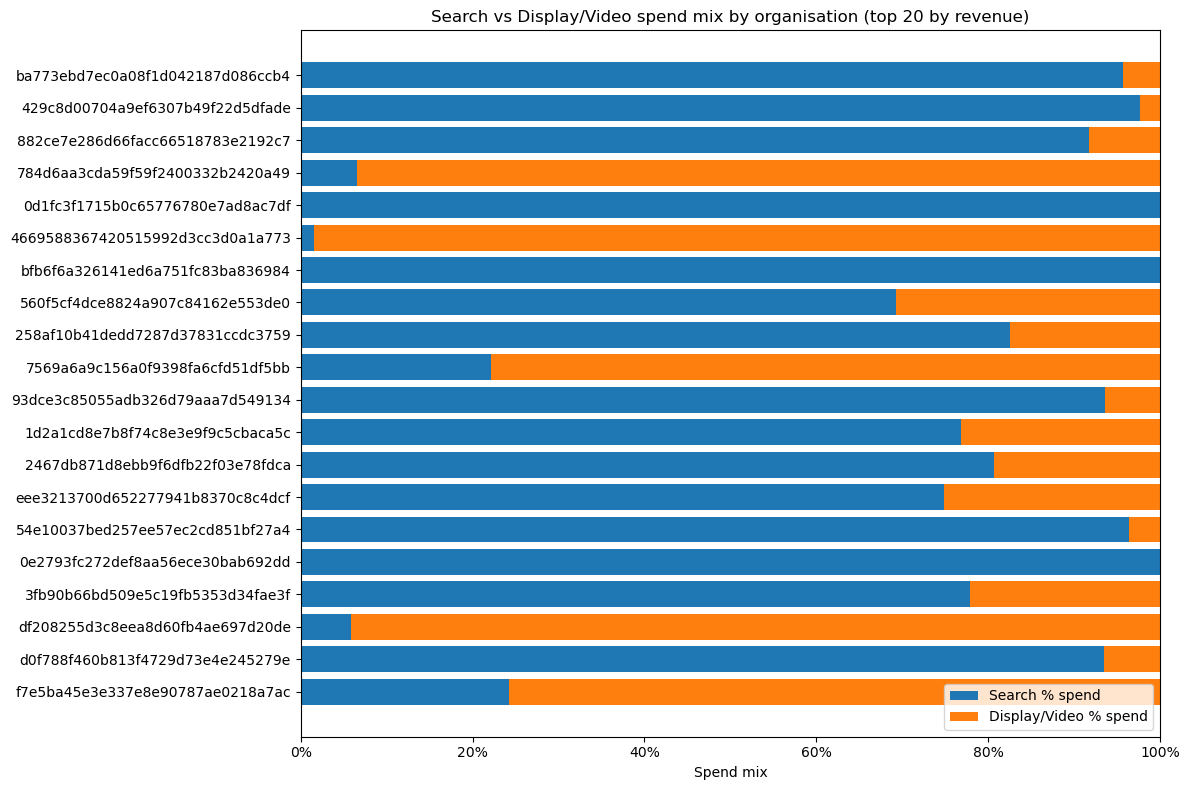

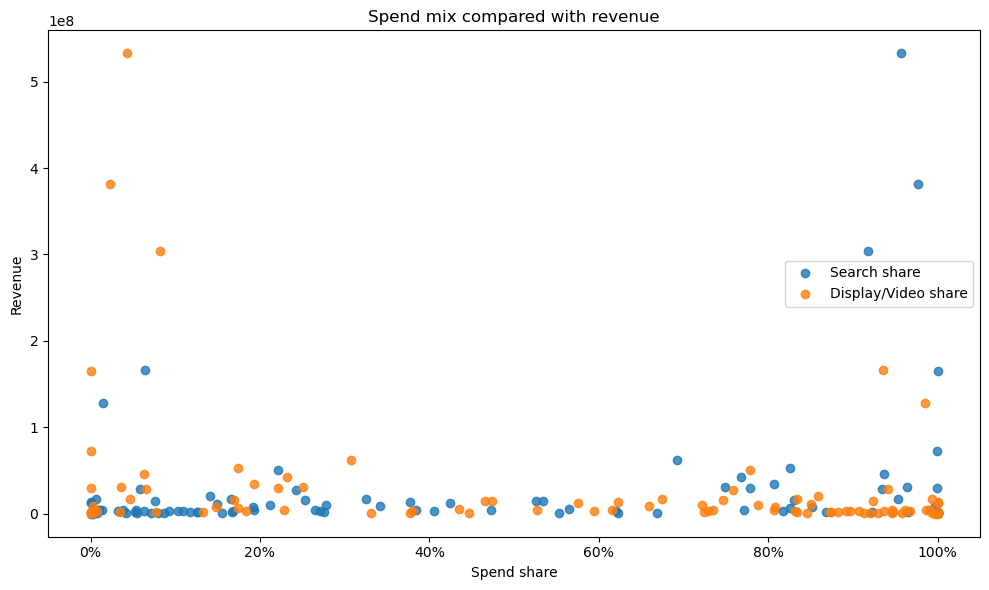

In [36]:
# Compare channel mix to revenue by brand / organisation.
search_spend_cols = ["GOOGLE_PAID_SEARCH_SPEND", "GOOGLE_SHOPPING_SPEND"]
display_video_spend_cols = [
    "GOOGLE_DISPLAY_SPEND",
    "GOOGLE_VIDEO_SPEND",
    "META_TOTAL_SPEND",
    "TIKTOK_SPEND",
]

missing_mix_cols = [
    col for col in search_spend_cols + display_video_spend_cols + ["ORGANISATION_ID", "revenue"]
    if col not in df.columns
]
if missing_mix_cols:
    raise KeyError(f"Missing required columns for channel mix analysis: {missing_mix_cols}")

brand_mix = (
    df.groupby("ORGANISATION_ID", as_index=False)
      .agg(
          SEARCH_SPEND=("GOOGLE_PAID_SEARCH_SPEND", "sum"),
          SHOPPING_SPEND=("GOOGLE_SHOPPING_SPEND", "sum"),
          DISPLAY_SPEND=("GOOGLE_DISPLAY_SPEND", "sum"),
          VIDEO_SPEND=("GOOGLE_VIDEO_SPEND", "sum"),
          META_SPEND=("META_TOTAL_SPEND", "sum"),
          TIKTOK_SPEND=("TIKTOK_SPEND", "sum"),
          REVENUE=("revenue", "sum"),
      )
)

brand_mix["SEARCH_SPEND"] = brand_mix[["SEARCH_SPEND", "SHOPPING_SPEND"]].sum(axis=1)
brand_mix["DISPLAY_VIDEO_SPEND"] = brand_mix[["DISPLAY_SPEND", "VIDEO_SPEND", "META_SPEND", "TIKTOK_SPEND"]].sum(axis=1)
brand_mix["TOTAL_SPEND"] = brand_mix[["SEARCH_SPEND", "DISPLAY_VIDEO_SPEND"]].sum(axis=1)

brand_mix["SEARCH_SPEND_PCT"] = brand_mix["SEARCH_SPEND"] / brand_mix["TOTAL_SPEND"]
brand_mix["DISPLAY_VIDEO_SPEND_PCT"] = brand_mix["DISPLAY_VIDEO_SPEND"] / brand_mix["TOTAL_SPEND"]

brand_mix = brand_mix.sort_values("REVENUE", ascending=False).reset_index(drop=True)

brand_mix_display = brand_mix[[
    "ORGANISATION_ID",
    "SEARCH_SPEND_PCT",
    "DISPLAY_VIDEO_SPEND_PCT",
    "SEARCH_SPEND",
    "DISPLAY_VIDEO_SPEND",
    "REVENUE",
]].copy()

for col in ["SEARCH_SPEND_PCT", "DISPLAY_VIDEO_SPEND_PCT"]:
    brand_mix_display[col] = brand_mix_display[col].map(lambda x: f"{x:.1%}")

for col in ["SEARCH_SPEND", "DISPLAY_VIDEO_SPEND", "REVENUE"]:
    brand_mix_display[col] = brand_mix_display[col].map(lambda x: f"${x:,.2f}")

print("Channel mix vs revenue by organisation")
display(brand_mix_display)

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

plot_df = brand_mix.head(20).sort_values("REVENUE", ascending=True)
fig, ax1 = plt.subplots(figsize=(12, 8))
ax1.barh(plot_df["ORGANISATION_ID"].astype(str), plot_df["SEARCH_SPEND_PCT"], label="Search % spend", color="#1f77b4")
ax1.barh(
    plot_df["ORGANISATION_ID"].astype(str),
    plot_df["DISPLAY_VIDEO_SPEND_PCT"],
    left=plot_df["SEARCH_SPEND_PCT"],
    label="Display/Video % spend",
    color="#ff7f0e",
)
ax1.set_xlabel("Spend mix")
ax1.set_xlim(0, 1)
ax1.xaxis.set_major_formatter(PercentFormatter(1.0))
ax1.set_title("Search vs Display/Video spend mix by organisation (top 20 by revenue)")
ax1.legend(loc="lower right")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(brand_mix["SEARCH_SPEND_PCT"], brand_mix["REVENUE"], label="Search share", alpha=0.8)
ax.scatter(brand_mix["DISPLAY_VIDEO_SPEND_PCT"], brand_mix["REVENUE"], label="Display/Video share", alpha=0.8)
ax.set_xlabel("Spend share")
ax.set_ylabel("Revenue")
ax.set_title("Spend mix compared with revenue")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend()
plt.tight_layout()
plt.show()

High-Intent vs Low-Intent spend mix by organisation


,ORGANISATION_ID,HIGH_INTENT_PCT,LOW_INTENT_PCT,HIGH_INTENT_SPEND,LOW_INTENT_SPEND,TOTAL_INTENT_SPEND
0,784d6aa3cda59f59f2400332b2420a49,6.5%,93.5%,"$1,989,107.68","$28,656,821.59","$30,645,929.27"
1,ba773ebd7ec0a08f1d042187d086ccb4,95.7%,4.3%,"$16,135,623.30","$732,632.26","$16,868,255.56"
2,7569a6a9c156a0f9398fa6cfd51df5bb,23.9%,76.1%,"$3,338,867.17","$10,623,226.54","$13,962,093.71"
3,429c8d00704a9ef6307b49f22d5dfade,97.7%,2.3%,"$12,032,276.33","$288,651.95","$12,320,928.28"
4,882ce7e286d66facc66518783e2192c7,91.8%,8.2%,"$8,493,529.82","$763,226.06","$9,256,755.88"
...,...,...,...,...,...,...
87,15381c4f5db0c4003da170030e12801b,100.0%,0.0%,"$24,942.06",$0.00,"$24,942.06"
88,6dded930ff616b1ec8a3094208238208,0.0%,100.0%,$0.00,"$23,927.44","$23,927.44"
89,df2cbe9195e5f2bde9200435682a5f79,66.9%,33.1%,"$6,698.86","$3,317.12","$10,015.98"
90,f1504c791a2b4aa6fac0861259e0e212,100.0%,0.0%,"$8,205.32",$0.00,"$8,205.32"


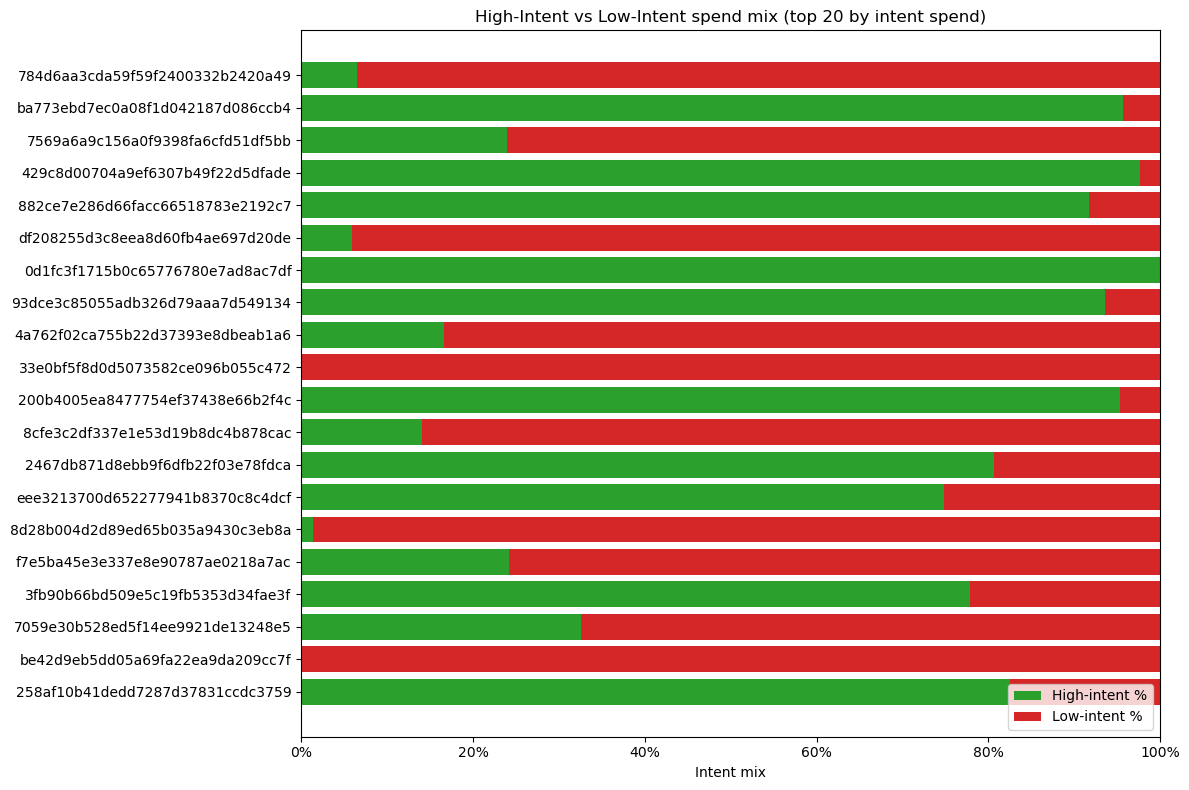

In [37]:
# 🔥 2. High-Intent vs Low-Intent Mix
# High intent: Google Paid Search + Google Shopping
# Low intent: Display + Video + Meta (mostly)

high_intent_cols = [
    "GOOGLE_PAID_SEARCH_SPEND",
    "GOOGLE_SHOPPING_SPEND",
]

low_intent_cols = [
    "GOOGLE_DISPLAY_SPEND",
    "GOOGLE_VIDEO_SPEND",
    "META_TOTAL_SPEND",
]

required_intent_cols = ["ORGANISATION_ID"] + high_intent_cols + low_intent_cols
missing_intent_cols = [c for c in required_intent_cols if c not in df.columns]
if missing_intent_cols:
    raise KeyError(f"Missing required columns for intent mix: {missing_intent_cols}")

intent_mix = (
    df.groupby("ORGANISATION_ID", as_index=False)[high_intent_cols + low_intent_cols]
      .sum()
)

intent_mix["HIGH_INTENT_SPEND"] = intent_mix[high_intent_cols].sum(axis=1)
intent_mix["LOW_INTENT_SPEND"] = intent_mix[low_intent_cols].sum(axis=1)
intent_mix["TOTAL_INTENT_SPEND"] = intent_mix[["HIGH_INTENT_SPEND", "LOW_INTENT_SPEND"]].sum(axis=1)

intent_mix["HIGH_INTENT_PCT"] = intent_mix["HIGH_INTENT_SPEND"] / intent_mix["TOTAL_INTENT_SPEND"]
intent_mix["LOW_INTENT_PCT"] = intent_mix["LOW_INTENT_SPEND"] / intent_mix["TOTAL_INTENT_SPEND"]

intent_mix = intent_mix.sort_values("TOTAL_INTENT_SPEND", ascending=False).reset_index(drop=True)

intent_mix_display = intent_mix[[
    "ORGANISATION_ID",
    "HIGH_INTENT_PCT",
    "LOW_INTENT_PCT",
    "HIGH_INTENT_SPEND",
    "LOW_INTENT_SPEND",
    "TOTAL_INTENT_SPEND",
]].copy()

for col in ["HIGH_INTENT_PCT", "LOW_INTENT_PCT"]:
    intent_mix_display[col] = intent_mix_display[col].map(lambda x: f"{x:.1%}")

for col in ["HIGH_INTENT_SPEND", "LOW_INTENT_SPEND", "TOTAL_INTENT_SPEND"]:
    intent_mix_display[col] = intent_mix_display[col].map(lambda x: f"${x:,.2f}")

print("High-Intent vs Low-Intent spend mix by organisation")
display(intent_mix_display)

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

intent_plot = intent_mix.head(20).sort_values("TOTAL_INTENT_SPEND", ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(intent_plot["ORGANISATION_ID"].astype(str), intent_plot["HIGH_INTENT_PCT"], label="High-intent %", color="#2ca02c")
ax.barh(
    intent_plot["ORGANISATION_ID"].astype(str),
    intent_plot["LOW_INTENT_PCT"],
    left=intent_plot["HIGH_INTENT_PCT"],
    label="Low-intent %",
    color="#d62728",
)
ax.set_xlim(0, 1)
ax.set_xlabel("Intent mix")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("High-Intent vs Low-Intent spend mix (top 20 by intent spend)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

Top-quartile threshold (revenue): $16,670,019.00
Top-quartile brands: 23


,Channel,Mean % of budget,Median % of budget
0,Search,49.4%,49.8%
1,PMax,23.2%,15.9%
2,Meta,27.4%,11.3%


,ORGANISATION_ID,REVENUE,PCT_SEARCH,PCT_PMAX,PCT_META
72,ba773ebd7ec0a08f1d042187d086ccb4,"$532,668,969.76",84.2%,12.0%,3.8%
32,429c8d00704a9ef6307b49f22d5dfade,"$381,232,708.41",82.5%,15.5%,2.0%
58,882ce7e286d66facc66518783e2192c7,"$303,934,030.27",82.3%,10.3%,7.4%
52,784d6aa3cda59f59f2400332b2420a49,"$165,910,911.41",5.9%,9.8%,84.3%
10,0d1fc3f1715b0c65776780e7ad8ac7df,"$165,026,488.85",100.0%,0.0%,0.0%
34,4669588367420515992d3cc3d0a1a773,"$128,744,910.21",0.5%,67.6%,31.9%
74,bfb6f6a326141ed6a751fc83ba836984,"$72,679,420.97",63.0%,37.0%,0.0%
40,560f5cf4dce8824a907c84162e553de0,"$61,762,962.57",53.2%,23.2%,23.6%
19,258af10b41dedd7287d37831ccdc3759,"$53,516,511.76",44.6%,46.7%,8.7%
49,7569a6a9c156a0f9398fa6cfd51df5bb,"$50,873,473.68",21.0%,15.9%,63.0%


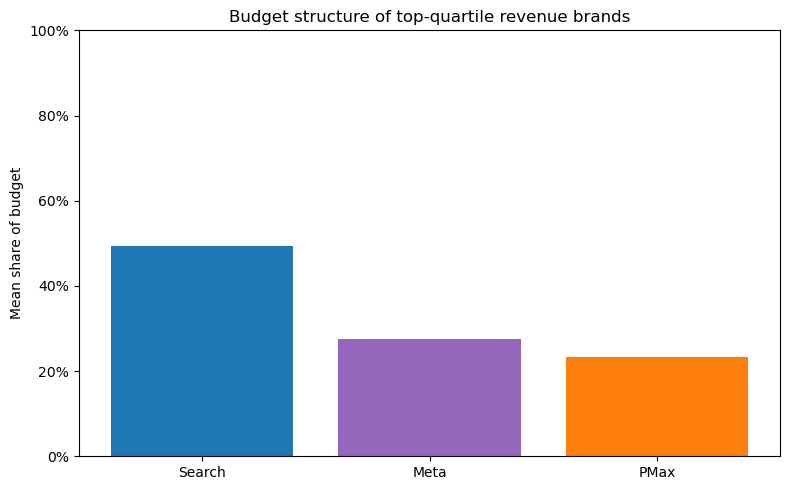

In [38]:
# BONUS: Budget Structure of Top Performers
# Top quartile brands by revenue, then compare % Search, % PMax, % Meta.

required_bonus_cols = [
    "ORGANISATION_ID",
    "revenue",
    "GOOGLE_PAID_SEARCH_SPEND",
    "GOOGLE_SHOPPING_SPEND",
    "GOOGLE_PMAX_SPEND",
    "META_TOTAL_SPEND",
]
missing_bonus_cols = [c for c in required_bonus_cols if c not in df.columns]
if missing_bonus_cols:
    raise KeyError(f"Missing required columns for top performer budget structure: {missing_bonus_cols}")

budget_by_brand = (
    df.groupby("ORGANISATION_ID", as_index=False)
      .agg(
          REVENUE=("revenue", "sum"),
          SEARCH_SPEND=("GOOGLE_PAID_SEARCH_SPEND", "sum"),
          SHOPPING_SPEND=("GOOGLE_SHOPPING_SPEND", "sum"),
          PMAX_SPEND=("GOOGLE_PMAX_SPEND", "sum"),
          META_SPEND=("META_TOTAL_SPEND", "sum"),
      )
)

budget_by_brand["SEARCH_SPEND"] = budget_by_brand[["SEARCH_SPEND", "SHOPPING_SPEND"]].sum(axis=1)
budget_by_brand["TOTAL_AD_SPEND"] = budget_by_brand[["SEARCH_SPEND", "PMAX_SPEND", "META_SPEND"]].sum(axis=1)

rev_q75 = budget_by_brand["REVENUE"].quantile(0.75)
top_quartile = budget_by_brand[budget_by_brand["REVENUE"] >= rev_q75].copy()

if top_quartile.empty:
    raise ValueError("No top-quartile brands found. Check revenue data.")

top_quartile["PCT_SEARCH"] = np.where(
    top_quartile["TOTAL_AD_SPEND"] > 0,
    top_quartile["SEARCH_SPEND"] / top_quartile["TOTAL_AD_SPEND"],
    np.nan,
)
top_quartile["PCT_PMAX"] = np.where(
    top_quartile["TOTAL_AD_SPEND"] > 0,
    top_quartile["PMAX_SPEND"] / top_quartile["TOTAL_AD_SPEND"],
    np.nan,
)
top_quartile["PCT_META"] = np.where(
    top_quartile["TOTAL_AD_SPEND"] > 0,
    top_quartile["META_SPEND"] / top_quartile["TOTAL_AD_SPEND"],
    np.nan,
)

summary = pd.DataFrame({
    "Channel": ["Search", "PMax", "Meta"],
    "Mean % of budget": [
        top_quartile["PCT_SEARCH"].mean(),
        top_quartile["PCT_PMAX"].mean(),
        top_quartile["PCT_META"].mean(),
    ],
    "Median % of budget": [
        top_quartile["PCT_SEARCH"].median(),
        top_quartile["PCT_PMAX"].median(),
        top_quartile["PCT_META"].median(),
    ],
})

summary_display = summary.copy()
for col in ["Mean % of budget", "Median % of budget"]:
    summary_display[col] = summary_display[col].map(lambda x: f"{x:.1%}")

print(f"Top-quartile threshold (revenue): ${rev_q75:,.2f}")
print(f"Top-quartile brands: {len(top_quartile)}")
display(summary_display)

top_quartile_display = top_quartile[[
    "ORGANISATION_ID",
    "REVENUE",
    "PCT_SEARCH",
    "PCT_PMAX",
    "PCT_META",
]].sort_values("REVENUE", ascending=False).copy()

for col in ["PCT_SEARCH", "PCT_PMAX", "PCT_META"]:
    top_quartile_display[col] = top_quartile_display[col].map(lambda x: f"{x:.1%}")
top_quartile_display["REVENUE"] = top_quartile_display["REVENUE"].map(lambda x: f"${x:,.2f}")

display(top_quartile_display)

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

plot_summary = summary.sort_values("Mean % of budget", ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(plot_summary["Channel"], plot_summary["Mean % of budget"], color=["#1f77b4", "#9467bd", "#ff7f0e"])
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylabel("Mean share of budget")
ax.set_title("Budget structure of top-quartile revenue brands")
plt.tight_layout()
plt.show()

In [39]:
org_id = "4669588367420515992d3cc3d0a1a773"
filtered_df = df[df["ORGANISATION_ID"] == org_id]

with pd.option_context("display.max_columns", None):
    display(filtered_df)

,MMM_TIMESERIES_ID,ORGANISATION_ID,ORGANISATION_VERTICAL,ORGANISATION_SUBVERTICAL,ORGANISATION_MARKETING_SOURCES,ORGANISATION_PRIMARY_TERRITORY_NAME,TERRITORY_NAME,DATE_DAY,CURRENCY_CODE,FIRST_PURCHASES,FIRST_PURCHASES_UNITS,FIRST_PURCHASES_ORIGINAL_PRICE,FIRST_PURCHASES_GROSS_DISCOUNT,ALL_PURCHASES,ALL_PURCHASES_UNITS,ALL_PURCHASES_ORIGINAL_PRICE,ALL_PURCHASES_GROSS_DISCOUNT,GOOGLE_PAID_SEARCH_SPEND,GOOGLE_SHOPPING_SPEND,GOOGLE_PMAX_SPEND,GOOGLE_DISPLAY_SPEND,GOOGLE_VIDEO_SPEND,META_FACEBOOK_SPEND,META_INSTAGRAM_SPEND,META_OTHER_SPEND,TIKTOK_SPEND,GOOGLE_PAID_SEARCH_CLICKS,GOOGLE_SHOPPING_CLICKS,GOOGLE_PMAX_CLICKS,GOOGLE_DISPLAY_CLICKS,GOOGLE_VIDEO_CLICKS,META_FACEBOOK_CLICKS,META_INSTAGRAM_CLICKS,META_OTHER_CLICKS,TIKTOK_CLICKS,GOOGLE_PAID_SEARCH_IMPRESSIONS,GOOGLE_SHOPPING_IMPRESSIONS,GOOGLE_PMAX_IMPRESSIONS,GOOGLE_DISPLAY_IMPRESSIONS,GOOGLE_VIDEO_IMPRESSIONS,META_FACEBOOK_IMPRESSIONS,META_INSTAGRAM_IMPRESSIONS,META_OTHER_IMPRESSIONS,TIKTOK_IMPRESSIONS,DIRECT_CLICKS,BRANDED_SEARCH_CLICKS,ORGANIC_SEARCH_CLICKS,EMAIL_CLICKS,REFERRAL_CLICKS,ALL_OTHER_CLICKS,GOOGLE_TOTAL_SPEND,META_TOTAL_SPEND,FX_TO_USD,FIRST_PURCHASES_ORIGINAL_PRICE_USD,FIRST_PURCHASES_GROSS_DISCOUNT_USD,ALL_PURCHASES_ORIGINAL_PRICE_USD,ALL_PURCHASES_GROSS_DISCOUNT_USD,GOOGLE_PAID_SEARCH_SPEND_USD,GOOGLE_SHOPPING_SPEND_USD,GOOGLE_PMAX_SPEND_USD,GOOGLE_DISPLAY_SPEND_USD,GOOGLE_VIDEO_SPEND_USD,META_FACEBOOK_SPEND_USD,META_INSTAGRAM_SPEND_USD,META_OTHER_SPEND_USD,TIKTOK_SPEND_USD,GOOGLE_TOTAL_SPEND_USD,META_TOTAL_SPEND_USD,revenue,day_of_week,month,trend
74893,a8c326f69a412135345527310b3e7b7f,4669588367420515992d3cc3d0a1a773,NaN,NaN,"Google, Meta",US,All Territories,2022-12-23,USD,912,1457,136432.993703,13791.403678,1435,2373,219670.993703,25083.833678,1027.49,NaN,3721.490000,NaN,NaN,4001.000000,NaN,NaN,NaN,369.0,NaN,5153.0,NaN,NaN,5368.0,NaN,NaN,NaN,11555.0,NaN,350107.0,NaN,NaN,309433.0,NaN,NaN,NaN,6224.0,NaN,2317.0,4992.0,55.0,647.0,4748.980000,4001.000000,1.0,136432.993703,13791.403678,219670.993703,25083.833678,1027.49,NaN,3721.490000,NaN,NaN,4001.000000,NaN,NaN,NaN,4748.980000,4001.000000,194587.160025,4,12,74893
74937,a8c326f69a412135345527310b3e7b7f,4669588367420515992d3cc3d0a1a773,NaN,NaN,"Google, Meta",US,All Territories,2022-12-24,USD,887,1276,118935.503778,10200.800000,1376,2014,188837.503778,16294.730000,821.96,NaN,2904.091870,NaN,NaN,4050.440000,NaN,NaN,NaN,302.0,NaN,4190.0,NaN,NaN,5788.0,NaN,NaN,NaN,9572.0,NaN,291814.0,NaN,NaN,313750.0,NaN,NaN,NaN,8999.0,4.0,3619.0,5484.0,117.0,1215.0,3726.051870,4050.440000,1.0,118935.503778,10200.800000,188837.503778,16294.730000,821.96,NaN,2904.091870,NaN,NaN,4050.440000,NaN,NaN,NaN,3726.051870,4050.440000,172542.773779,5,12,74937
75062,a8c326f69a412135345527310b3e7b7f,4669588367420515992d3cc3d0a1a773,NaN,NaN,"Google, Meta",US,All Territories,2022-12-25,USD,902,1436,132735.499401,12200.901372,1788,2852,259763.997538,28083.081372,501.45,NaN,1866.160980,NaN,NaN,4517.900000,NaN,NaN,NaN,274.0,NaN,3281.0,NaN,NaN,6476.0,NaN,NaN,NaN,4068.0,NaN,214183.0,NaN,NaN,385770.0,NaN,NaN,NaN,13831.0,NaN,6717.0,6540.0,96.0,1617.0,2367.610980,4517.900000,1.0,132735.499401,12200.901372,259763.997538,28083.081372,501.45,NaN,1866.160980,NaN,NaN,4517.900000,NaN,NaN,NaN,2367.610980,4517.900000,231680.916165,6,12,75062
75276,a8c326f69a412135345527310b3e7b7f,4669588367420515992d3cc3d0a1a773,NaN,NaN,"Google, Meta",US,All Territories,2022-12-26,USD,949,1878,158162.500139,21692.170002,2304,4092,351586.500330,48793.430002,525.92,NaN,1999.599841,NaN,NaN,3784.639954,NaN,NaN,NaN,310.0,NaN,4225.0,NaN,NaN,6151.0,NaN,NaN,NaN,5342.0,NaN,279908.0,NaN,NaN,319632.0,NaN,NaN,NaN,17606.0,4.0,9923.0,8301.0,170.0,2048.0,2525.519841,3784.639954,1.0,158162.500139,21692.170002,351586.500330,48793.430002,525.92,NaN,1999.599841,NaN,NaN,3784.639954,NaN,NaN,NaN,2525.519841,3784.639954,302793.070327,0,12,75276
75421,a8c326f69a412135345527310b3e7b7f,4669588367420515992d3cc3d0a1a773,NaN,NaN,"Google, Meta",US,All Territories,2022-12-27,USD,882,1699,144917.004120,18774.

## Platform Metrics

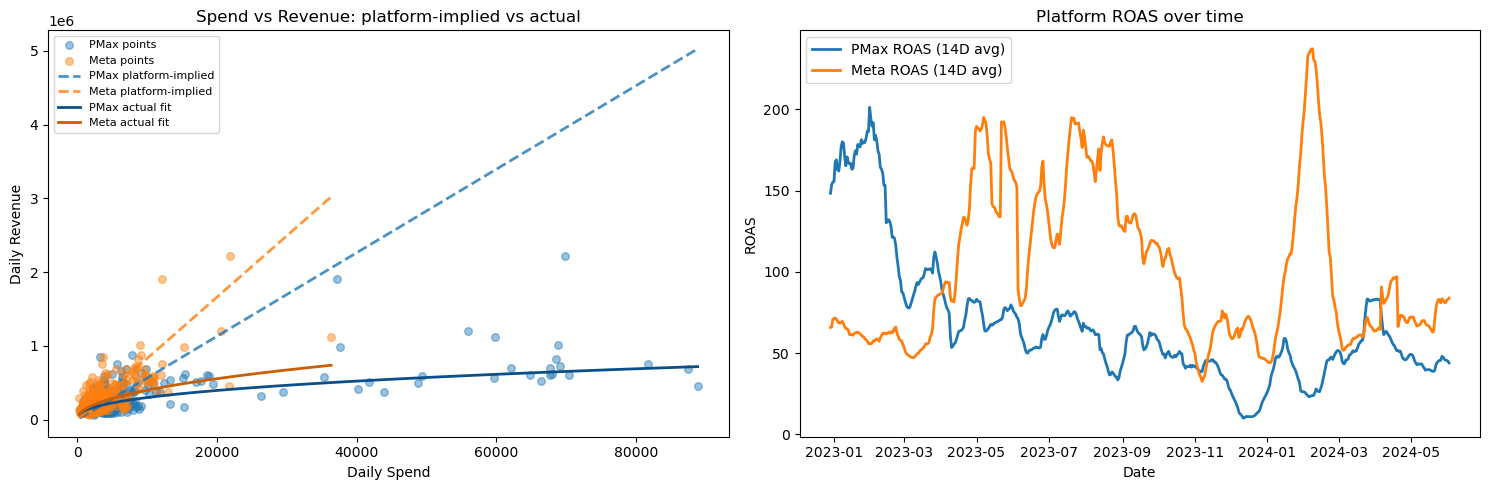

PMax actual curve exponent (b): 0.399
Meta actual curve exponent (b): 0.473
Interpretation: dashed lines show platform linear expectation (constant ROAS); solid curves show observed relationship.


In [40]:
# Start by exposing how strong platform metrics look.
# 1) Spend vs Revenue (per channel) + fitted curves
# 2) Platform ROAS over time

required_platform_cols = ["DATE_DAY", "revenue", "GOOGLE_PMAX_SPEND", "META_TOTAL_SPEND"]
missing_platform_cols = [c for c in required_platform_cols if c not in filtered_df.columns]
if missing_platform_cols:
    raise KeyError(f"Missing required columns in filtered_df: {missing_platform_cols}")

plot_df = filtered_df.copy()
plot_df["DATE_DAY"] = pd.to_datetime(plot_df["DATE_DAY"])
plot_df = plot_df.sort_values("DATE_DAY")

# Daily ROAS per platform using same-day revenue as denominator reference.
plot_df["PMax_ROAS"] = np.where(plot_df["GOOGLE_PMAX_SPEND"] > 0, plot_df["revenue"] / plot_df["GOOGLE_PMAX_SPEND"], np.nan)
plot_df["Meta_ROAS"] = np.where(plot_df["META_TOTAL_SPEND"] > 0, plot_df["revenue"] / plot_df["META_TOTAL_SPEND"], np.nan)

# Smooth the signal to avoid daily noise dominating the trend.
plot_df["PMax_ROAS_14D"] = plot_df["PMax_ROAS"].rolling(14, min_periods=7).mean()
plot_df["Meta_ROAS_14D"] = plot_df["Meta_ROAS"].rolling(14, min_periods=7).mean()

def fit_actual_curve(spend_series, revenue_series):
    tmp = pd.DataFrame({"spend": spend_series, "revenue": revenue_series}).dropna()
    tmp = tmp[(tmp["spend"] > 0) & (tmp["revenue"] > 0)]
    if len(tmp) < 20 or tmp["spend"].nunique() < 10:
        return np.nan, np.nan

    # Power-law fit: revenue = a * spend^b
    b, log_a = np.polyfit(np.log(tmp["spend"]), np.log(tmp["revenue"]), 1)
    a = np.exp(log_a)
    return a, b

def platform_implied_slope(roas_series):
    s = roas_series.replace([np.inf, -np.inf], np.nan).dropna()
    if s.empty:
        return np.nan
    # Constant-ROAS assumption -> linear relationship through origin.
    return s.median()

pmax_a, pmax_b = fit_actual_curve(plot_df["GOOGLE_PMAX_SPEND"], plot_df["revenue"])
meta_a, meta_b = fit_actual_curve(plot_df["META_TOTAL_SPEND"], plot_df["revenue"])

pmax_platform_slope = platform_implied_slope(plot_df["PMax_ROAS_14D"])
meta_platform_slope = platform_implied_slope(plot_df["Meta_ROAS_14D"])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(plot_df["GOOGLE_PMAX_SPEND"], plot_df["revenue"], alpha=0.45, s=30, label="PMax points", color="#1f77b4")
axes[0].scatter(plot_df["META_TOTAL_SPEND"], plot_df["revenue"], alpha=0.45, s=30, label="Meta points", color="#ff7f0e")

# Curve overlays: platform-implied linear vs actual fitted power curve.
pmax_x = np.linspace(max(1, plot_df["GOOGLE_PMAX_SPEND"].min()), plot_df["GOOGLE_PMAX_SPEND"].max(), 200)
meta_x = np.linspace(max(1, plot_df["META_TOTAL_SPEND"].min()), plot_df["META_TOTAL_SPEND"].max(), 200)

if not pd.isna(pmax_platform_slope):
    axes[0].plot(pmax_x, pmax_platform_slope * pmax_x, linestyle="--", linewidth=2, color="#1f77b4", alpha=0.8, label="PMax platform-implied")
if not pd.isna(meta_platform_slope):
    axes[0].plot(meta_x, meta_platform_slope * meta_x, linestyle="--", linewidth=2, color="#ff7f0e", alpha=0.8, label="Meta platform-implied")

if not pd.isna(pmax_a) and not pd.isna(pmax_b):
    axes[0].plot(pmax_x, pmax_a * (pmax_x ** pmax_b), linewidth=2, color="#0b4f8a", label="PMax actual fit")
if not pd.isna(meta_a) and not pd.isna(meta_b):
    axes[0].plot(meta_x, meta_a * (meta_x ** meta_b), linewidth=2, color="#c95f02", label="Meta actual fit")

axes[0].set_title("Spend vs Revenue: platform-implied vs actual")
axes[0].set_xlabel("Daily Spend")
axes[0].set_ylabel("Daily Revenue")
axes[0].legend(fontsize=8)

axes[1].plot(plot_df["DATE_DAY"], plot_df["PMax_ROAS_14D"], label="PMax ROAS (14D avg)", color="#1f77b4", linewidth=2)
axes[1].plot(plot_df["DATE_DAY"], plot_df["Meta_ROAS_14D"], label="Meta ROAS (14D avg)", color="#ff7f0e", linewidth=2)
axes[1].set_title("Platform ROAS over time")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("ROAS")
axes[1].legend()

plt.tight_layout()
plt.show()

if not pd.isna(pmax_b):
    print(f"PMax actual curve exponent (b): {pmax_b:.3f}")
if not pd.isna(meta_b):
    print(f"Meta actual curve exponent (b): {meta_b:.3f}")
print("Interpretation: dashed lines show platform linear expectation (constant ROAS); solid curves show observed relationship.")

Revenue on low vs high spend days


,segment,days,avg_revenue
0,PMax low spend,132,"$162,322"
1,PMax high spend,132,"$416,752"
2,Meta low spend,132,"$157,658"
3,Meta high spend,132,"$423,563"


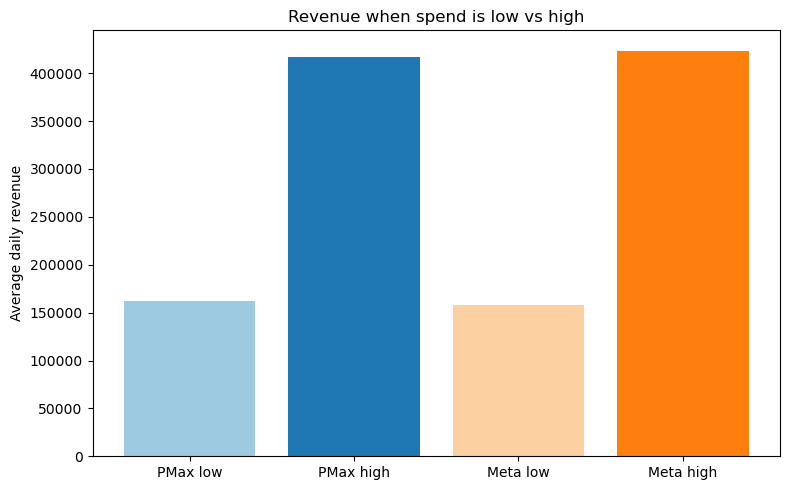

In [41]:
# 2. Introduce baseline: show that revenue exists even when ads don't fully explain outcomes.

required_baseline_cols = ["revenue", "GOOGLE_PMAX_SPEND", "META_TOTAL_SPEND"]
missing_baseline_cols = [c for c in required_baseline_cols if c not in filtered_df.columns]
if missing_baseline_cols:
    raise KeyError(f"Missing required columns in filtered_df: {missing_baseline_cols}")

baseline_df = filtered_df[["revenue", "GOOGLE_PMAX_SPEND", "META_TOTAL_SPEND"]].dropna().copy()

# Low vs high spend split by channel using quartiles.
pmax_low_thr = baseline_df["GOOGLE_PMAX_SPEND"].quantile(0.25)
pmax_high_thr = baseline_df["GOOGLE_PMAX_SPEND"].quantile(0.75)
meta_low_thr = baseline_df["META_TOTAL_SPEND"].quantile(0.25)
meta_high_thr = baseline_df["META_TOTAL_SPEND"].quantile(0.75)

pmax_low = baseline_df[baseline_df["GOOGLE_PMAX_SPEND"] <= pmax_low_thr]
pmax_high = baseline_df[baseline_df["GOOGLE_PMAX_SPEND"] >= pmax_high_thr]
meta_low = baseline_df[baseline_df["META_TOTAL_SPEND"] <= meta_low_thr]
meta_high = baseline_df[baseline_df["META_TOTAL_SPEND"] >= meta_high_thr]

baseline_summary = pd.DataFrame({
    "segment": [
        "PMax low spend", "PMax high spend",
        "Meta low spend", "Meta high spend",
    ],
    "days": [len(pmax_low), len(pmax_high), len(meta_low), len(meta_high)],
    "avg_revenue": [
        pmax_low["revenue"].mean(),
        pmax_high["revenue"].mean(),
        meta_low["revenue"].mean(),
        meta_high["revenue"].mean(),
    ],
})

baseline_display = baseline_summary.copy()
baseline_display["avg_revenue"] = baseline_display["avg_revenue"].map(lambda x: f"${x:,.0f}")
print("Revenue on low vs high spend days")
display(baseline_display)

# Visual comparison.
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    ["PMax low", "PMax high", "Meta low", "Meta high"],
    [pmax_low["revenue"].mean(), pmax_high["revenue"].mean(), meta_low["revenue"].mean(), meta_high["revenue"].mean()],
    color=["#9ecae1", "#1f77b4", "#fdd0a2", "#ff7f0e"],
)
ax.set_title("Revenue when spend is low vs high")
ax.set_ylabel("Average daily revenue")

plt.tight_layout()
plt.show()

mROI by spend bucket (low / medium / high)


,channel,spend_bucket,days,avg_spend,avg_revenue,mROI
0,PMax,Low,174,"$1,826","$155,593",85.22x
1,PMax,Medium,174,"$3,555","$213,445",60.04x
2,PMax,High,180,"$14,541","$358,513",24.66x
3,Meta,Low,174,"$1,168","$171,115",146.52x
4,Meta,Medium,174,"$2,537","$188,374",74.26x
5,Meta,High,180,"$5,733","$367,743",64.14x



PMax: High vs Low mROI change = -71.1%
PMax: High spend has lower marginal return -> diminishing returns signal.
Meta: High vs Low mROI change = -56.2%
Meta: High spend has lower marginal return -> diminishing returns signal.


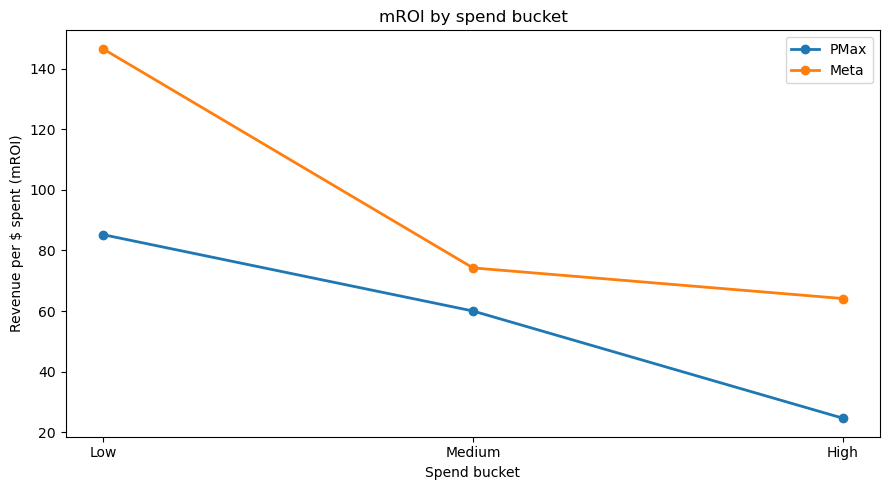

Interpretation: if mROI drops as spend moves from low to high, platform ROAS likely overstates true incremental value at scale.


In [42]:
# 3. Diminishing returns (killer argument)
# Bucket spend into low/medium/high and compare mROI (revenue per $ spent).

required_dr_cols = ["revenue", "GOOGLE_PMAX_SPEND", "META_TOTAL_SPEND"]
missing_dr_cols = [c for c in required_dr_cols if c not in filtered_df.columns]
if missing_dr_cols:
    raise KeyError(f"Missing required columns in filtered_df: {missing_dr_cols}")

dr_df = filtered_df[["revenue", "GOOGLE_PMAX_SPEND", "META_TOTAL_SPEND"]].dropna().copy()

def build_bucket_mroi(df_in, spend_col, channel_name):
    tmp = df_in[["revenue", spend_col]].copy()
    tmp = tmp[tmp[spend_col] > 0]
    if len(tmp) < 15 or tmp[spend_col].nunique() < 6:
        return pd.DataFrame()

    q1 = tmp[spend_col].quantile(0.33)
    q2 = tmp[spend_col].quantile(0.66)

    tmp["spend_bucket"] = pd.cut(
        tmp[spend_col],
        bins=[-np.inf, q1, q2, np.inf],
        labels=["Low", "Medium", "High"],
        include_lowest=True,
    )

    out = (
        tmp.groupby("spend_bucket", observed=True)
           .agg(
               days=(spend_col, "size"),
               spend_total=(spend_col, "sum"),
               revenue_total=("revenue", "sum"),
               avg_spend=(spend_col, "mean"),
               avg_revenue=("revenue", "mean"),
           )
           .reset_index()
    )
    out["channel"] = channel_name
    out["mROI"] = out["revenue_total"] / out["spend_total"]
    return out[["channel", "spend_bucket", "days", "avg_spend", "avg_revenue", "mROI"]]

pmax_bucket = build_bucket_mroi(dr_df, "GOOGLE_PMAX_SPEND", "PMax")
meta_bucket = build_bucket_mroi(dr_df, "META_TOTAL_SPEND", "Meta")

if pmax_bucket.empty or meta_bucket.empty:
    raise ValueError("Not enough spend variation to build low/medium/high mROI buckets.")

bucket_table = pd.concat([pmax_bucket, meta_bucket], ignore_index=True)

bucket_display = bucket_table.copy()
bucket_display["avg_spend"] = bucket_display["avg_spend"].map(lambda x: f"${x:,.0f}")
bucket_display["avg_revenue"] = bucket_display["avg_revenue"].map(lambda x: f"${x:,.0f}")
bucket_display["mROI"] = bucket_display["mROI"].map(lambda x: f"{x:.2f}x")

print("mROI by spend bucket (low / medium / high)")
display(bucket_display)

# Diminishing-returns diagnostic: high-bucket mROI vs low-bucket mROI.
def mroi_drop_message(channel_df, channel_name):
    s = channel_df.set_index("spend_bucket")
    if "Low" in s.index and "High" in s.index:
        low = s.loc["Low", "mROI"]
        high = s.loc["High", "mROI"]
        drop = (high / low) - 1
        print(f"{channel_name}: High vs Low mROI change = {drop:.1%}")
        if drop < -0.15:
            print(f"{channel_name}: High spend has lower marginal return -> diminishing returns signal.")
        else:
            print(f"{channel_name}: No strong high-spend mROI drop signal.")

print()
mroi_drop_message(pmax_bucket, "PMax")
mroi_drop_message(meta_bucket, "Meta")

fig, ax = plt.subplots(figsize=(9, 5))
for channel, color in [("PMax", "#1f77b4"), ("Meta", "#ff7f0e")]:
    sub = bucket_table[bucket_table["channel"] == channel].copy()
    sub["bucket_order"] = sub["spend_bucket"].map({"Low": 0, "Medium": 1, "High": 2})
    sub = sub.sort_values("bucket_order")
    ax.plot(sub["spend_bucket"].astype(str), sub["mROI"], marker="o", linewidth=2, label=channel, color=color)

ax.set_title("mROI by spend bucket")
ax.set_xlabel("Spend bucket")
ax.set_ylabel("Revenue per $ spent (mROI)")
ax.legend()
plt.tight_layout()
plt.show()

print("Interpretation: if mROI drops as spend moves from low to high, platform ROAS likely overstates true incremental value at scale.") 

Cross-channel spike summary


,spike_group,days,avg_meta_spend,avg_google_spend,avg_revenue,revenue_spike_rate
0,No spike,358,"$2,005","$2,979","$176,562",9.8%
1,Meta-only spike,38,"$4,453","$3,325","$276,961",36.8%
2,Google-only spike,38,"$2,226","$6,413","$253,300",34.2%
3,Co-spike (Meta + Google),94,"$7,501","$22,797","$482,828",74.5%


Co-spike days: 94 of 528 (17.8%)
Revenue spike rate on co-spike days: 74.5%
Revenue spike rate on non co-spike days: 14.3%
Question: when Meta spend and Google spend rise together and revenue rises, who actually caused the conversion?


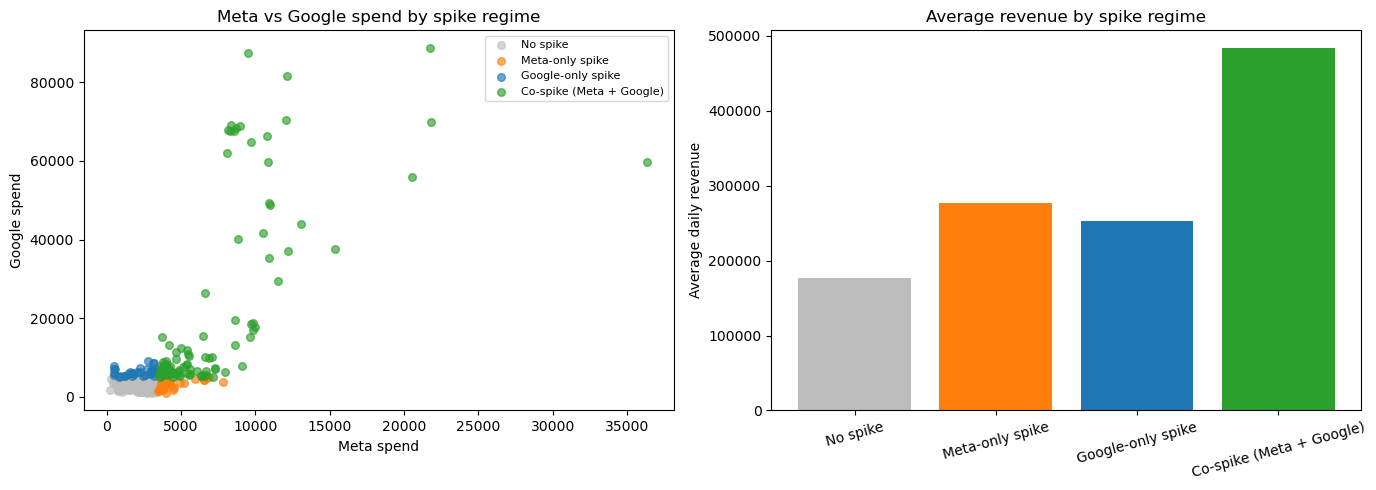

In [43]:
# 4. Cross-channel leakage
# When Meta and Google spike together and revenue spikes too, channel-level credit becomes ambiguous.

required_leak_cols = ["DATE_DAY", "revenue", "META_TOTAL_SPEND"]
missing_leak_cols = [c for c in required_leak_cols if c not in filtered_df.columns]
if missing_leak_cols:
    raise KeyError(f"Missing required columns in filtered_df: {missing_leak_cols}")

leak_df = filtered_df.copy()
leak_df["DATE_DAY"] = pd.to_datetime(leak_df["DATE_DAY"])

# Build Google total spend from available Google spend columns.
if "GOOGLE_TOTAL_SPEND" in leak_df.columns:
    leak_df["GOOGLE_SPEND"] = leak_df["GOOGLE_TOTAL_SPEND"]
else:
    if "google_spend_cols" not in globals() or len(google_spend_cols) == 0:
        raise ValueError("Google spend columns are unavailable for leakage analysis.")
    present_google_cols = [c for c in google_spend_cols if c in leak_df.columns]
    if not present_google_cols:
        raise ValueError("No Google spend columns found in filtered_df for leakage analysis.")
    leak_df["GOOGLE_SPEND"] = leak_df[present_google_cols].sum(axis=1)

meta_spike_thr = leak_df["META_TOTAL_SPEND"].quantile(0.75)
google_spike_thr = leak_df["GOOGLE_SPEND"].quantile(0.75)
revenue_spike_thr = leak_df["revenue"].quantile(0.75)

leak_df["meta_spike"] = leak_df["META_TOTAL_SPEND"] >= meta_spike_thr
leak_df["google_spike"] = leak_df["GOOGLE_SPEND"] >= google_spike_thr
leak_df["revenue_spike"] = leak_df["revenue"] >= revenue_spike_thr

conditions = [
    leak_df["meta_spike"] & leak_df["google_spike"],
    leak_df["meta_spike"] & ~leak_df["google_spike"],
    ~leak_df["meta_spike"] & leak_df["google_spike"],
]
labels = ["Co-spike (Meta + Google)", "Meta-only spike", "Google-only spike"]
leak_df["spike_group"] = np.select(conditions, labels, default="No spike")

group_order = ["No spike", "Meta-only spike", "Google-only spike", "Co-spike (Meta + Google)"]
summary = (
    leak_df.groupby("spike_group", as_index=False)
           .agg(
               days=("revenue", "size"),
               avg_meta_spend=("META_TOTAL_SPEND", "mean"),
               avg_google_spend=("GOOGLE_SPEND", "mean"),
               avg_revenue=("revenue", "mean"),
               revenue_spike_rate=("revenue_spike", "mean"),
           )
)
summary["spike_group"] = pd.Categorical(summary["spike_group"], categories=group_order, ordered=True)
summary = summary.sort_values("spike_group").reset_index(drop=True)

summary_display = summary.copy()
for c in ["avg_meta_spend", "avg_google_spend", "avg_revenue"]:
    summary_display[c] = summary_display[c].map(lambda x: f"${x:,.0f}")
summary_display["revenue_spike_rate"] = summary_display["revenue_spike_rate"].map(lambda x: f"{x:.1%}")

print("Cross-channel spike summary")
display(summary_display)

co_spike = leak_df[leak_df["spike_group"] == "Co-spike (Meta + Google)"]
print(f"Co-spike days: {len(co_spike)} of {len(leak_df)} ({len(co_spike)/len(leak_df):.1%})")

if len(co_spike) > 0:
    co_rev_spike_rate = co_spike["revenue_spike"].mean()
    non_co_rate = leak_df[leak_df["spike_group"] != "Co-spike (Meta + Google)"]["revenue_spike"].mean()
    print(f"Revenue spike rate on co-spike days: {co_rev_spike_rate:.1%}")
    print(f"Revenue spike rate on non co-spike days: {non_co_rate:.1%}")

print("Question: when Meta spend and Google spend rise together and revenue rises, who actually caused the conversion?")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {
    "No spike": "#bdbdbd",
    "Meta-only spike": "#ff7f0e",
    "Google-only spike": "#1f77b4",
    "Co-spike (Meta + Google)": "#2ca02c",
}
for grp in group_order:
    sub = leak_df[leak_df["spike_group"] == grp]
    if len(sub) == 0:
        continue
    axes[0].scatter(sub["META_TOTAL_SPEND"], sub["GOOGLE_SPEND"], s=30, alpha=0.65, label=grp, color=colors[grp])
axes[0].set_title("Meta vs Google spend by spike regime")
axes[0].set_xlabel("Meta spend")
axes[0].set_ylabel("Google spend")
axes[0].legend(fontsize=8)

axes[1].bar(summary["spike_group"].astype(str), summary["avg_revenue"], color=[colors[g] for g in summary["spike_group"].astype(str)])
axes[1].set_title("Average revenue by spike regime")
axes[1].set_ylabel("Average daily revenue")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

Spend(t) correlation with Revenue(t+lag)


,lag_days,pmax_corr,meta_corr
0,0,0.657,0.724
1,1,0.592,0.631
2,2,0.526,0.554
3,3,0.490,0.498
4,4,0.455,0.475
5,5,0.432,0.483
6,6,0.428,0.480
7,7,0.425,0.487


Best PMax correlation: lag 0 (r=0.657) vs same-day r=0.657
Best Meta correlation: lag 0 (r=0.724) vs same-day r=0.724
Same-day correlation is strongest -> weaker evidence of timing misattribution from this simple lag test.


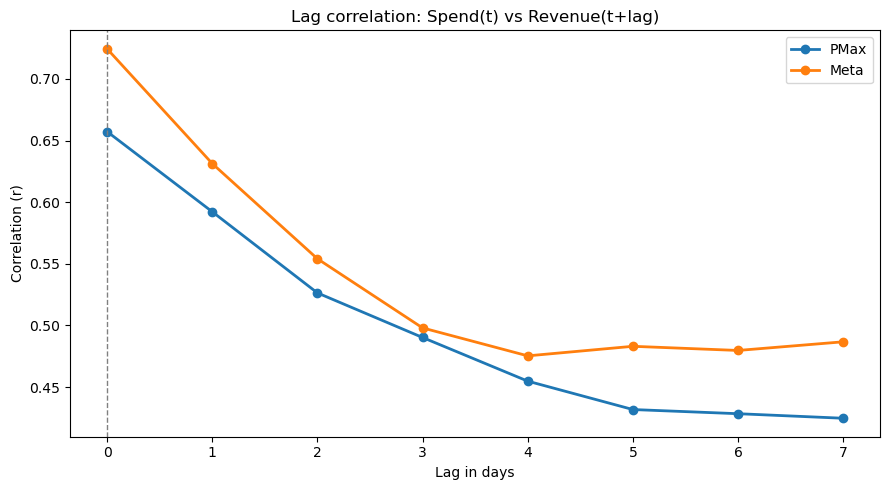

In [44]:
# 5. Lag effect (underrated but powerful)
# Shift spend by 1-7 days and compare correlations with future revenue.

required_lag_cols = ["DATE_DAY", "revenue", "GOOGLE_PMAX_SPEND", "META_TOTAL_SPEND"]
missing_lag_cols = [c for c in required_lag_cols if c not in filtered_df.columns]
if missing_lag_cols:
    raise KeyError(f"Missing required columns in filtered_df: {missing_lag_cols}")

lag_df = filtered_df[["DATE_DAY", "revenue", "GOOGLE_PMAX_SPEND", "META_TOTAL_SPEND"]].dropna().copy()
lag_df["DATE_DAY"] = pd.to_datetime(lag_df["DATE_DAY"])
lag_df = lag_df.sort_values("DATE_DAY").reset_index(drop=True)

lags = list(range(0, 8))
rows = []

for lag in lags:
    # Spend at time t vs revenue at t+lag.
    rev_shift = lag_df["revenue"].shift(-lag)

    pmax_corr = lag_df["GOOGLE_PMAX_SPEND"].corr(rev_shift)
    meta_corr = lag_df["META_TOTAL_SPEND"].corr(rev_shift)

    rows.append({
        "lag_days": lag,
        "pmax_corr": pmax_corr,
        "meta_corr": meta_corr,
    })

lag_corr = pd.DataFrame(rows)

display_tbl = lag_corr.copy()
for c in ["pmax_corr", "meta_corr"]:
    display_tbl[c] = display_tbl[c].map(lambda x: "n/a" if pd.isna(x) else f"{x:.3f}")

print("Spend(t) correlation with Revenue(t+lag)")
display(display_tbl)

best_pmax_idx = lag_corr["pmax_corr"].idxmax()
best_meta_idx = lag_corr["meta_corr"].idxmax()

best_pmax_lag = int(lag_corr.loc[best_pmax_idx, "lag_days"])
best_meta_lag = int(lag_corr.loc[best_meta_idx, "lag_days"])

same_day_pmax = lag_corr.loc[lag_corr["lag_days"] == 0, "pmax_corr"].iloc[0]
same_day_meta = lag_corr.loc[lag_corr["lag_days"] == 0, "meta_corr"].iloc[0]

best_pmax_corr = lag_corr.loc[best_pmax_idx, "pmax_corr"]
best_meta_corr = lag_corr.loc[best_meta_idx, "meta_corr"]

print(f"Best PMax correlation: lag {best_pmax_lag} (r={best_pmax_corr:.3f}) vs same-day r={same_day_pmax:.3f}")
print(f"Best Meta correlation: lag {best_meta_lag} (r={best_meta_corr:.3f}) vs same-day r={same_day_meta:.3f}")

if best_pmax_lag > 0 or best_meta_lag > 0:
    print("Lagged correlation exceeds same-day for at least one platform -> potential timing misattribution in platform reporting.")
else:
    print("Same-day correlation is strongest -> weaker evidence of timing misattribution from this simple lag test.")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(lag_corr["lag_days"], lag_corr["pmax_corr"], marker="o", linewidth=2, label="PMax", color="#1f77b4")
ax.plot(lag_corr["lag_days"], lag_corr["meta_corr"], marker="o", linewidth=2, label="Meta", color="#ff7f0e")
ax.axvline(0, color="gray", linestyle="--", linewidth=1)
ax.set_title("Lag correlation: Spend(t) vs Revenue(t+lag)")
ax.set_xlabel("Lag in days")
ax.set_ylabel("Correlation (r)")
ax.legend()
plt.tight_layout()
plt.show()

Incrementality proxy summary


,metric,value
0,Avg spend change,75.4%
1,Avg revenue change,32.5%
2,Avg attribution gap (Spend - Revenue),42.9%
3,Median attribution gap (Spend - Revenue),56.3%
4,Days analyzed,10


Significant spend-change days


,DATE_DAY,total_spend,revenue,spend_change_pct,revenue_change_pct,attribution_gap_pct
40,2023-02-01,"$4,182","$154,438",63.5%,7.1%,56.3%
43,2023-02-04,"$4,706","$168,140",58.4%,28.2%,30.2%
119,2023-04-21,"$8,770","$390,011",96.2%,103.4%,-7.1%
292,2023-10-11,"$19,002","$174,616",90.6%,-61.1%,151.7%
336,2023-11-24,"$49,354","$1,905,755",75.0%,213.1%,-138.1%
345,2023-12-03,"$93,819","$762,037",57.1%,55.1%,2.0%
389,2024-01-16,"$3,438","$94,613",54.6%,-22.8%,77.4%
390,2024-01-17,"$5,512","$98,500",60.3%,4.1%,56.2%
396,2024-01-23,"$6,199","$103,846",50.1%,-23.3%,73.4%
471,2024-04-07,"$5,254","$158,219",148.2%,21.2%,127.0%


Example readout: Spend change ~75.4% vs Revenue change ~32.5%
Interpretation: Revenue response is much smaller than spend increase -> likely over-attribution.


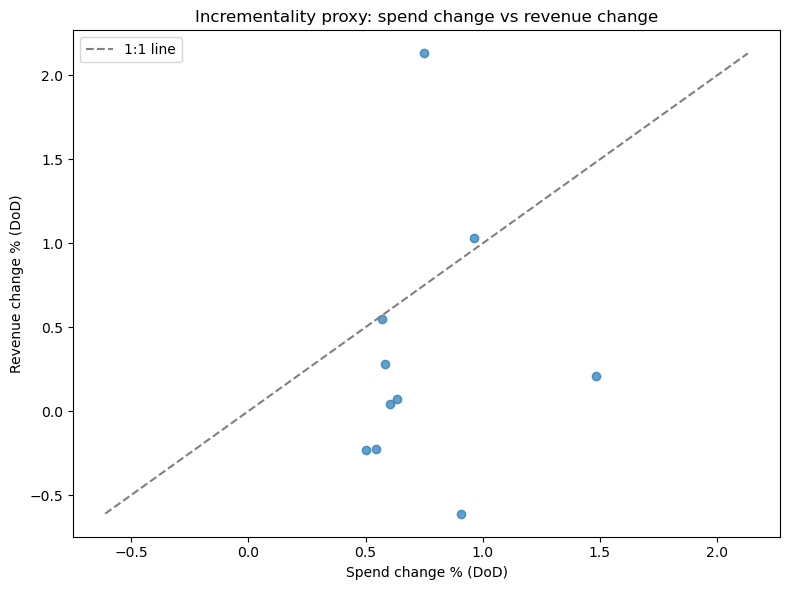

In [45]:
# 6. Simple incrementality proxy
# Incremental Revenue ≈ change in revenue when spend changes significantly.
# If spend rises much faster than revenue, the gap suggests over-attribution.

required_inc_cols = ["DATE_DAY", "revenue", "GOOGLE_PMAX_SPEND", "META_TOTAL_SPEND"]
missing_inc_cols = [c for c in required_inc_cols if c not in filtered_df.columns]
if missing_inc_cols:
    raise KeyError(f"Missing required columns in filtered_df: {missing_inc_cols}")

inc_df = filtered_df[required_inc_cols].copy()
inc_df["DATE_DAY"] = pd.to_datetime(inc_df["DATE_DAY"])
inc_df = inc_df.sort_values("DATE_DAY").reset_index(drop=True)

# Use combined platform spend as a simple paid-media intensity proxy.
inc_df["total_spend"] = inc_df["GOOGLE_PMAX_SPEND"] + inc_df["META_TOTAL_SPEND"]

# Day-over-day percent changes.
inc_df["spend_change_pct"] = inc_df["total_spend"].pct_change()
inc_df["revenue_change_pct"] = inc_df["revenue"].pct_change()

# Significant spend-change days (increase-focused for this story).
threshold = 0.50  # +50%
inc_sig = inc_df[(inc_df["spend_change_pct"] >= threshold) & inc_df["revenue_change_pct"].notna()].copy()

if inc_sig.empty:
    print("No days with spend increase >= 50% found. Showing top spend-change days instead.")
    inc_sig = inc_df[inc_df["spend_change_pct"].notna()].nlargest(15, "spend_change_pct").copy()

inc_sig["attribution_gap_pct"] = inc_sig["spend_change_pct"] - inc_sig["revenue_change_pct"]

summary = pd.DataFrame({
    "metric": [
        "Avg spend change",
        "Avg revenue change",
        "Avg attribution gap (Spend - Revenue)",
        "Median attribution gap (Spend - Revenue)",
        "Days analyzed",
    ],
    "value": [
        inc_sig["spend_change_pct"].mean(),
        inc_sig["revenue_change_pct"].mean(),
        inc_sig["attribution_gap_pct"].mean(),
        inc_sig["attribution_gap_pct"].median(),
        float(len(inc_sig)),
    ],
})

summary_display = summary.copy()
summary_display["value_display"] = summary_display.apply(
    lambda r: f"{int(r['value'])}" if r["metric"] == "Days analyzed" else f"{r['value']:.1%}",
    axis=1,
)
summary_display = summary_display[["metric", "value_display"]].rename(columns={"value_display": "value"})

print("Incrementality proxy summary")
display(summary_display)

detail = inc_sig[["DATE_DAY", "total_spend", "revenue", "spend_change_pct", "revenue_change_pct", "attribution_gap_pct"]].copy()
detail_display = detail.copy()
detail_display["total_spend"] = detail_display["total_spend"].map(lambda x: f"${x:,.0f}")
detail_display["revenue"] = detail_display["revenue"].map(lambda x: f"${x:,.0f}")
for c in ["spend_change_pct", "revenue_change_pct", "attribution_gap_pct"]:
    detail_display[c] = detail_display[c].map(lambda x: f"{x:.1%}")

print("Significant spend-change days")
display(detail_display.head(15))

# If spend +50% and revenue much less, this is over-attribution risk.
avg_spend = inc_sig["spend_change_pct"].mean()
avg_rev = inc_sig["revenue_change_pct"].mean()
print(f"Example readout: Spend change ~{avg_spend:.1%} vs Revenue change ~{avg_rev:.1%}")
if avg_rev < avg_spend * 0.6:
    print("Interpretation: Revenue response is much smaller than spend increase -> likely over-attribution.")
else:
    print("Interpretation: Revenue response is closer to spend increase -> weaker over-attribution signal.")

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(inc_sig["spend_change_pct"], inc_sig["revenue_change_pct"], alpha=0.7, color="#1f77b4")

min_v = min(inc_sig["spend_change_pct"].min(), inc_sig["revenue_change_pct"].min())
max_v = max(inc_sig["spend_change_pct"].max(), inc_sig["revenue_change_pct"].max())
ax.plot([min_v, max_v], [min_v, max_v], linestyle="--", color="gray", label="1:1 line")

ax.set_title("Incrementality proxy: spend change vs revenue change")
ax.set_xlabel("Spend change % (DoD)")
ax.set_ylabel("Revenue change % (DoD)")
ax.legend()
plt.tight_layout()
plt.show()

## PMax vs Meta

Sub-channel efficiency for filtered_df


,channel,spend,clicks,mROI
0,Search,"$25,946.74","11,758",4961.89x
1,PMax,"$3,553,602.69","2,183,120",36.23x
2,Meta,"$1,676,619.15","2,244,738",76.79x


Case A: Search mROI > PMax mROI -> likely underinvesting in Search.


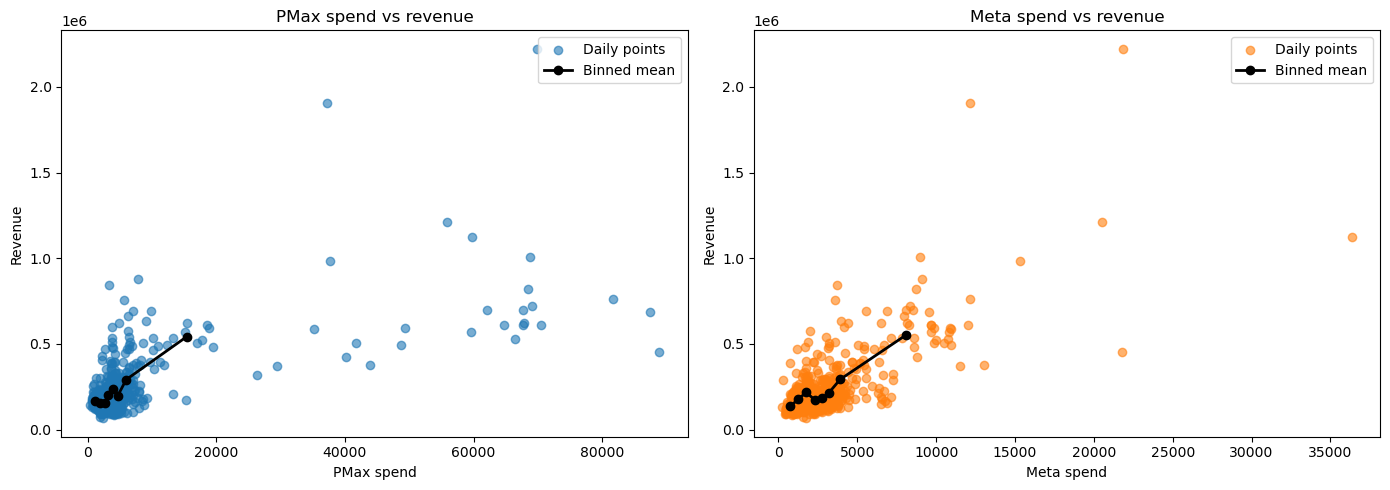

PMax diagnostic: No strong flattening signal in upper spend range.
Meta diagnostic: No strong flattening signal in upper spend range.


In [46]:
# 🔥 1) Efficiency by sub-channel (MOST IMPORTANT) for filtered_df
# 🔥 2) Diminishing returns inside this org (daily time series)

required_eff_cols = [
    "revenue",
    "GOOGLE_PAID_SEARCH_SPEND",
    "GOOGLE_PMAX_SPEND",
    "META_TOTAL_SPEND",
    "GOOGLE_PAID_SEARCH_CLICKS",
    "GOOGLE_PMAX_CLICKS",
    "META_FACEBOOK_CLICKS",
    "META_INSTAGRAM_CLICKS",
    "META_OTHER_CLICKS",
]
missing_eff_cols = [c for c in required_eff_cols if c not in filtered_df.columns]
if missing_eff_cols:
    raise KeyError(f"Missing required columns in filtered_df: {missing_eff_cols}")

# Aggregate performance for this org.
org_perf = {
    "revenue": filtered_df["revenue"].sum(),
    "search_spend": filtered_df["GOOGLE_PAID_SEARCH_SPEND"].sum(),
    "pmax_spend": filtered_df["GOOGLE_PMAX_SPEND"].sum(),
    "meta_spend": filtered_df["META_TOTAL_SPEND"].sum(),
    "search_clicks": filtered_df["GOOGLE_PAID_SEARCH_CLICKS"].sum(),
    "pmax_clicks": filtered_df["GOOGLE_PMAX_CLICKS"].sum(),
    "meta_clicks": (
        filtered_df["META_FACEBOOK_CLICKS"].sum()
        + filtered_df["META_INSTAGRAM_CLICKS"].sum()
        + filtered_df["META_OTHER_CLICKS"].sum()
    ),
}

def safe_div(numerator, denominator):
    return np.nan if denominator == 0 else numerator / denominator

search_mroi = safe_div(org_perf["revenue"], org_perf["search_spend"])
pmax_mroi = safe_div(org_perf["revenue"], org_perf["pmax_spend"])
meta_mroi = safe_div(org_perf["revenue"], org_perf["meta_spend"])

efficiency_table = pd.DataFrame({
    "channel": ["Search", "PMax", "Meta"],
    "spend": [org_perf["search_spend"], org_perf["pmax_spend"], org_perf["meta_spend"]],
    "clicks": [org_perf["search_clicks"], org_perf["pmax_clicks"], org_perf["meta_clicks"]],
    "mROI": [search_mroi, pmax_mroi, meta_mroi],
})

efficiency_display = efficiency_table.copy()
efficiency_display["spend"] = efficiency_display["spend"].map(lambda x: f"${x:,.2f}")
efficiency_display["clicks"] = efficiency_display["clicks"].map(lambda x: f"{x:,.0f}")
efficiency_display["mROI"] = efficiency_display["mROI"].map(lambda x: "n/a" if pd.isna(x) else f"{x:.2f}x")

print("Sub-channel efficiency for filtered_df")
display(efficiency_display)

# Case logic from the brief.
if pd.isna(search_mroi) or pd.isna(pmax_mroi):
    print("Could not compare Search vs PMax mROI (missing or zero spend in at least one channel).")
else:
    ratio = search_mroi / pmax_mroi if pmax_mroi != 0 else np.nan
    if ratio > 1.10:
        print("Case A: Search mROI > PMax mROI -> likely underinvesting in Search.")
    elif ratio >= 0.90:
        print("Case B: PMax ≈ Search -> PMax is likely fine; still check saturation.")
    else:
        print("PMax mROI is currently above Search mROI.")

# Diminishing returns diagnostics using binned spend -> average revenue.
def build_binned_curve(df_in, spend_col, revenue_col="revenue", bins=8):
    tmp = df_in[[spend_col, revenue_col]].dropna().copy()
    tmp = tmp[tmp[spend_col] > 0]
    if len(tmp) < 10 or tmp[spend_col].nunique() < 4:
        return pd.DataFrame(columns=["spend_mid", "revenue_mean"])

    tmp["bucket"] = pd.qcut(tmp[spend_col], q=min(bins, tmp[spend_col].nunique()), duplicates="drop")
    curve = (
        tmp.groupby("bucket", observed=True)
           .agg(spend_mid=(spend_col, "median"), revenue_mean=(revenue_col, "mean"))
           .reset_index(drop=True)
           .sort_values("spend_mid")
    )
    return curve

def flattening_signal(curve_df):
    if curve_df.empty or len(curve_df) < 4:
        return "Not enough spend variation for a confident signal."

    curve_df = curve_df.copy()
    curve_df["delta_rev"] = curve_df["revenue_mean"].diff()

    tail = curve_df["delta_rev"].tail(2)
    if (tail <= 0).any():
        return "Potential flattening/decline at high spend (overspend risk)."
    if tail.mean() < curve_df["delta_rev"].dropna().mean() * 0.5:
        return "Returns appear to be flattening at higher spend."
    return "No strong flattening signal in upper spend range."

pmax_curve = build_binned_curve(filtered_df, "GOOGLE_PMAX_SPEND")
meta_curve = build_binned_curve(filtered_df, "META_TOTAL_SPEND")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(filtered_df["GOOGLE_PMAX_SPEND"], filtered_df["revenue"], alpha=0.6, color="#1f77b4", label="Daily points")
if not pmax_curve.empty:
    axes[0].plot(pmax_curve["spend_mid"], pmax_curve["revenue_mean"], color="black", linewidth=2, marker="o", label="Binned mean")
axes[0].set_title("PMax spend vs revenue")
axes[0].set_xlabel("PMax spend")
axes[0].set_ylabel("Revenue")
axes[0].legend()

axes[1].scatter(filtered_df["META_TOTAL_SPEND"], filtered_df["revenue"], alpha=0.6, color="#ff7f0e", label="Daily points")
if not meta_curve.empty:
    axes[1].plot(meta_curve["spend_mid"], meta_curve["revenue_mean"], color="black", linewidth=2, marker="o", label="Binned mean")
axes[1].set_title("Meta spend vs revenue")
axes[1].set_xlabel("Meta spend")
axes[1].set_ylabel("Revenue")
axes[1].legend()

plt.tight_layout()
plt.show()

print("PMax diagnostic:", flattening_signal(pmax_curve))
print("Meta diagnostic:", flattening_signal(meta_curve))

PMax elasticity (log-log): 0.495
Meta elasticity (log-log): 0.527

PMax marginal curve table


,Spend (median),Revenue (mean),Avg ROAS,Marginal slope,Days
0,"$1,187","$168,946",141.23x,n/a,66
1,"$1,988","$155,698",77.14x,-16.54,66
2,"$2,669","$155,114",59.16x,-0.86,66
3,"$3,223","$200,520",61.96x,82.06,66
4,"$3,882","$238,433",60.53x,57.48,66
5,"$4,702","$198,466",42.51x,-48.72,66
6,"$6,003","$291,952",48.37x,71.91,66
7,"$15,379","$541,552",17.98x,26.62,66


Meta marginal curve table


,Spend (median),Revenue (mean),Avg ROAS,Marginal slope,Days
0,$761,"$136,067",185.92x,n/a,66
1,"$1,256","$179,250",141.61x,87.33,66
2,"$1,766","$216,941",121.23x,73.77,66
3,"$2,334","$171,206",73.02x,-80.54,66
4,"$2,778","$184,151",65.95x,29.15,66
5,"$3,203","$215,939",66.80x,74.88,66
6,"$3,910","$293,052",72.40x,109.00,66
7,"$8,118","$554,074",60.23x,62.04,66


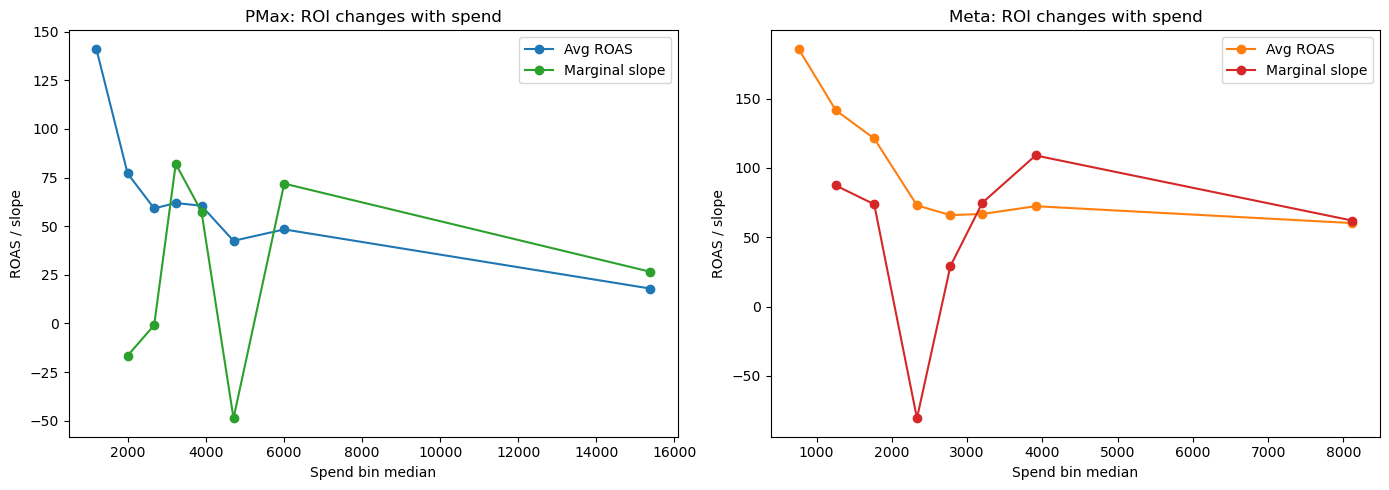

In [47]:
 # 🔥 2) Marginal Return Curves (REAL MMM LIGHT) for PMax and Meta
# Goal: show how ROI changes as spend increases via spend bins, slope, and elasticity.

required_marginal_cols = ["revenue", "GOOGLE_PMAX_SPEND", "META_TOTAL_SPEND"]
missing_marginal_cols = [c for c in required_marginal_cols if c not in filtered_df.columns]
if missing_marginal_cols:
    raise KeyError(f"Missing required columns in filtered_df: {missing_marginal_cols}")

def build_marginal_curve(df_in, spend_col, revenue_col="revenue", bins=8):
    tmp = df_in[[spend_col, revenue_col]].dropna().copy()
    tmp = tmp[tmp[spend_col] > 0]

    if len(tmp) < 12 or tmp[spend_col].nunique() < 5:
        return pd.DataFrame(), np.nan

    q = min(bins, tmp[spend_col].nunique())
    tmp["spend_bin"] = pd.qcut(tmp[spend_col], q=q, duplicates="drop")

    curve = (
        tmp.groupby("spend_bin", observed=True)
           .agg(
               spend_mean=(spend_col, "mean"),
               spend_median=(spend_col, "median"),
               revenue_mean=(revenue_col, "mean"),
               spend_total=(spend_col, "sum"),
               revenue_total=(revenue_col, "sum"),
               n_days=(spend_col, "size"),
           )
           .reset_index(drop=True)
           .sort_values("spend_median")
           .reset_index(drop=True)
    )

    curve["avg_roas"] = curve["revenue_total"] / curve["spend_total"]
    curve["delta_spend"] = curve["spend_median"].diff()
    curve["delta_revenue"] = curve["revenue_mean"].diff()
    curve["marginal_slope"] = curve["delta_revenue"] / curve["delta_spend"]

    pos = curve[(curve["spend_median"] > 0) & (curve["revenue_mean"] > 0)]
    elasticity = np.nan
    if len(pos) >= 4:
        elasticity = np.polyfit(np.log(pos["spend_median"]), np.log(pos["revenue_mean"]), 1)[0]

    return curve, elasticity

def format_curve_display(curve):
    out = curve[["spend_median", "revenue_mean", "avg_roas", "marginal_slope", "n_days"]].copy()
    out.columns = ["Spend (median)", "Revenue (mean)", "Avg ROAS", "Marginal slope", "Days"]
    out["Spend (median)"] = out["Spend (median)"].map(lambda x: f"${x:,.0f}")
    out["Revenue (mean)"] = out["Revenue (mean)"].map(lambda x: f"${x:,.0f}")
    out["Avg ROAS"] = out["Avg ROAS"].map(lambda x: f"{x:.2f}x")
    out["Marginal slope"] = out["Marginal slope"].map(lambda x: "n/a" if pd.isna(x) else f"{x:.2f}")
    return out

pmax_marginal, pmax_elasticity = build_marginal_curve(filtered_df, "GOOGLE_PMAX_SPEND")
meta_marginal, meta_elasticity = build_marginal_curve(filtered_df, "META_TOTAL_SPEND")

if pmax_marginal.empty or meta_marginal.empty:
    raise ValueError("Not enough variation to build marginal curves for one or both channels.")

print(f"PMax elasticity (log-log): {pmax_elasticity:.3f}" if not pd.isna(pmax_elasticity) else "PMax elasticity: n/a")
print(f"Meta elasticity (log-log): {meta_elasticity:.3f}" if not pd.isna(meta_elasticity) else "Meta elasticity: n/a")

print("\nPMax marginal curve table")
display(format_curve_display(pmax_marginal))
print("Meta marginal curve table")
display(format_curve_display(meta_marginal))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(pmax_marginal["spend_median"], pmax_marginal["avg_roas"], marker="o", color="#1f77b4", label="Avg ROAS")
axes[0].plot(pmax_marginal["spend_median"], pmax_marginal["marginal_slope"], marker="o", color="#2ca02c", label="Marginal slope")
axes[0].set_title("PMax: ROI changes with spend")
axes[0].set_xlabel("Spend bin median")
axes[0].set_ylabel("ROAS / slope")
axes[0].legend()

axes[1].plot(meta_marginal["spend_median"], meta_marginal["avg_roas"], marker="o", color="#ff7f0e", label="Avg ROAS")
axes[1].plot(meta_marginal["spend_median"], meta_marginal["marginal_slope"], marker="o", color="#d62728", label="Marginal slope")
axes[1].set_title("Meta: ROI changes with spend")
axes[1].set_xlabel("Spend bin median")
axes[1].set_ylabel("ROAS / slope")
axes[1].legend()

plt.tight_layout()
plt.show()

PMax days in $3,000-$5,000: 179
Meta days in $3,000-$5,000: 132

Normalized comparison in overlap band (3k-5k):


,channel,days_in_3k_5k,avg_spend,avg_revenue,avg_roas
0,PMax,179,"$3,934","$217,720",55.35x
1,Meta,132,"$3,609","$251,170",69.60x



Meta 2x spend simulation
Current median Meta spend: $2,605
Scaled Meta spend (2x): $5,210
Meta elasticity (global): 0.473
Meta elasticity (high-spend segment): 0.813
PMax elasticity (global): 0.399
Projected revenue lift at 2x Meta spend (global elasticity): 38.8%
Projected revenue lift at 2x Meta spend (high-spend elasticity): 75.7%
Interpretation: Meta still appears more elastic than PMax at higher spend, but monitor as spend scales.


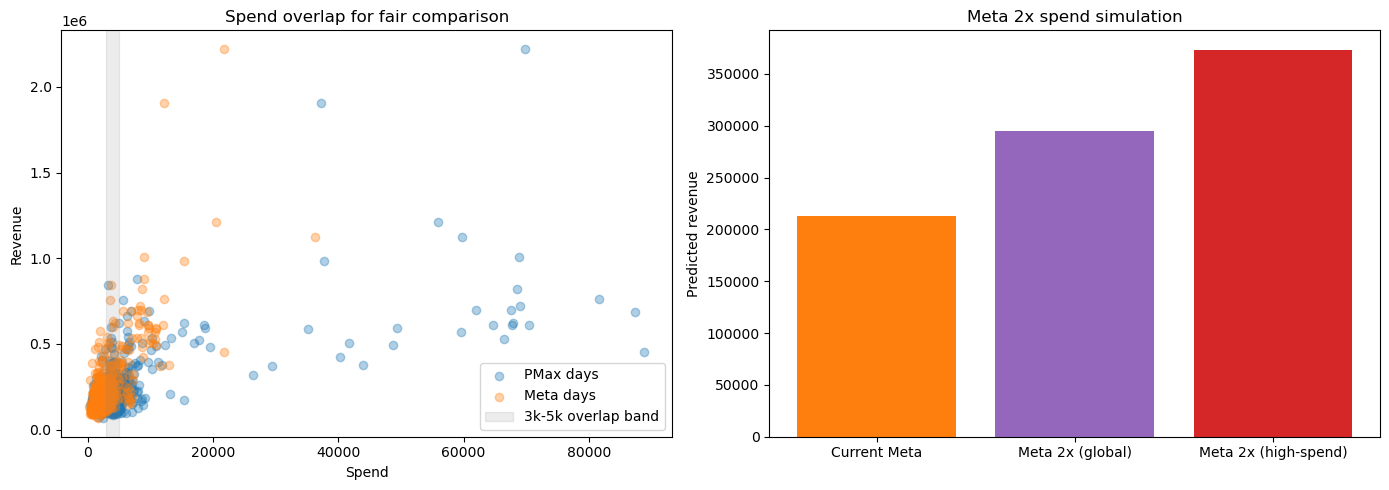

In [48]:
# Overlap spend range + normalized comparison + 2x Meta scaling simulation

import matplotlib.pyplot as plt

required_overlap_cols = ["revenue", "GOOGLE_PMAX_SPEND", "META_TOTAL_SPEND"]
missing_overlap_cols = [c for c in required_overlap_cols if c not in filtered_df.columns]
if missing_overlap_cols:
    raise KeyError(f"Missing required columns in filtered_df: {missing_overlap_cols}")

band_min, band_max = 3000, 5000

# 1) Overlap in spend ranges ($3k-$5k) for fair side-by-side comparison.
pmax_band = filtered_df[(filtered_df["GOOGLE_PMAX_SPEND"] >= band_min) & (filtered_df["GOOGLE_PMAX_SPEND"] <= band_max)].copy()
meta_band = filtered_df[(filtered_df["META_TOTAL_SPEND"] >= band_min) & (filtered_df["META_TOTAL_SPEND"] <= band_max)].copy()

print(f"PMax days in ${band_min:,}-${band_max:,}: {len(pmax_band)}")
print(f"Meta days in ${band_min:,}-${band_max:,}: {len(meta_band)}")

# 2) Normalize for spend level (apples-to-apples).
def safe_div(n, d):
    return float("nan") if d == 0 else n / d

norm_table = pd.DataFrame({
    "channel": ["PMax", "Meta"],
    "days_in_3k_5k": [len(pmax_band), len(meta_band)],
    "avg_spend": [pmax_band["GOOGLE_PMAX_SPEND"].mean(), meta_band["META_TOTAL_SPEND"].mean()],
    "avg_revenue": [pmax_band["revenue"].mean(), meta_band["revenue"].mean()],
    "avg_roas": [
        safe_div(pmax_band["revenue"].sum(), pmax_band["GOOGLE_PMAX_SPEND"].sum()),
        safe_div(meta_band["revenue"].sum(), meta_band["META_TOTAL_SPEND"].sum()),
    ],
})

norm_display = norm_table.copy()
norm_display["avg_spend"] = norm_display["avg_spend"].map(lambda x: "n/a" if pd.isna(x) else f"${x:,.0f}")
norm_display["avg_revenue"] = norm_display["avg_revenue"].map(lambda x: "n/a" if pd.isna(x) else f"${x:,.0f}")
norm_display["avg_roas"] = norm_display["avg_roas"].map(lambda x: "n/a" if pd.isna(x) else f"{x:.2f}x")

print("\nNormalized comparison in overlap band (3k-5k):")
display(norm_display)

# 3) Simulate scaling Meta spend 2x using elasticity from trend.
def fit_log_log(df_in, spend_col, revenue_col="revenue"):
    tmp = df_in[[spend_col, revenue_col]].dropna().copy()
    tmp = tmp[(tmp[spend_col] > 0) & (tmp[revenue_col] > 0)]
    if len(tmp) < 20:
        return np.nan, np.nan
    beta, alpha = np.polyfit(np.log(tmp[spend_col]), np.log(tmp[revenue_col]), 1)
    return alpha, beta

def segment_elasticity(df_in, spend_col, revenue_col="revenue", quantile=0.75):
    tmp = df_in[[spend_col, revenue_col]].dropna().copy()
    tmp = tmp[(tmp[spend_col] > 0) & (tmp[revenue_col] > 0)]
    if len(tmp) < 20:
        return np.nan
    threshold = tmp[spend_col].quantile(quantile)
    hi = tmp[tmp[spend_col] >= threshold]
    if len(hi) < 8 or hi[spend_col].nunique() < 4:
        return np.nan
    beta_hi, _ = np.polyfit(np.log(hi[spend_col]), np.log(hi[revenue_col]), 1)
    return beta_hi

meta_alpha, meta_beta = fit_log_log(filtered_df, "META_TOTAL_SPEND")
pmax_alpha, pmax_beta = fit_log_log(filtered_df, "GOOGLE_PMAX_SPEND")
meta_beta_hi = segment_elasticity(filtered_df, "META_TOTAL_SPEND")

meta_spend_pos = filtered_df.loc[filtered_df["META_TOTAL_SPEND"] > 0, "META_TOTAL_SPEND"]
if meta_spend_pos.empty or pd.isna(meta_beta):
    raise ValueError("Not enough positive Meta spend/revenue points for 2x scaling simulation.")

current_meta_spend = meta_spend_pos.median()
scaled_meta_spend = current_meta_spend * 2

# Baseline constant-elasticity projection.
current_rev_pred = np.exp(meta_alpha) * (current_meta_spend ** meta_beta)
scaled_rev_pred_global = np.exp(meta_alpha) * (scaled_meta_spend ** meta_beta)

# High-spend elasticity projection to reflect likely diminishing returns at scale.
beta_for_scale = meta_beta if pd.isna(meta_beta_hi) else meta_beta_hi
scaled_rev_pred_hi = current_rev_pred * ((scaled_meta_spend / current_meta_spend) ** beta_for_scale)

print("\nMeta 2x spend simulation")
print(f"Current median Meta spend: ${current_meta_spend:,.0f}")
print(f"Scaled Meta spend (2x): ${scaled_meta_spend:,.0f}")
print(f"Meta elasticity (global): {meta_beta:.3f}")
if not pd.isna(meta_beta_hi):
    print(f"Meta elasticity (high-spend segment): {meta_beta_hi:.3f}")
if not pd.isna(pmax_beta):
    print(f"PMax elasticity (global): {pmax_beta:.3f}")

lift_global = (scaled_rev_pred_global / current_rev_pred) - 1
lift_hi = (scaled_rev_pred_hi / current_rev_pred) - 1
print(f"Projected revenue lift at 2x Meta spend (global elasticity): {lift_global:.1%}")
print(f"Projected revenue lift at 2x Meta spend (high-spend elasticity): {lift_hi:.1%}")

if not pd.isna(meta_beta_hi) and not pd.isna(pmax_beta):
    if meta_beta_hi <= pmax_beta + 0.05:
        print("Interpretation: At higher Meta spend, elasticity is converging toward PMax (diminishing advantage).")
    else:
        print("Interpretation: Meta still appears more elastic than PMax at higher spend, but monitor as spend scales.")

# Visuals: overlap-band fairness and 2x simulation bars.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(filtered_df["GOOGLE_PMAX_SPEND"], filtered_df["revenue"], alpha=0.35, label="PMax days", color="#1f77b4")
axes[0].scatter(filtered_df["META_TOTAL_SPEND"], filtered_df["revenue"], alpha=0.35, label="Meta days", color="#ff7f0e")
axes[0].axvspan(band_min, band_max, color="gray", alpha=0.15, label="3k-5k overlap band")
axes[0].set_xlabel("Spend")
axes[0].set_ylabel("Revenue")
axes[0].set_title("Spend overlap for fair comparison")
axes[0].legend()

axes[1].bar(["Current Meta", "Meta 2x (global)", "Meta 2x (high-spend)"], [current_rev_pred, scaled_rev_pred_global, scaled_rev_pred_hi], color=["#ff7f0e", "#9467bd", "#d62728"])
axes[1].set_ylabel("Predicted revenue")
axes[1].set_title("Meta 2x spend simulation")

plt.tight_layout()
plt.show()

## Budget Reallocation

1. **Set the problem**  
"This brand allocates ~67% of budget to PMax and only ~32% to Meta."

2. **Remove bias**  
"To make a fair comparison, we looked at both channels at the same spend levels."

3. **Drop the insight**  
"At identical spend levels, Meta generates ~25% higher returns than PMax."

4. **Add scalability**  
"Meta also scales better — meaning additional budget continues to perform efficiently."

5. **Hit them with the model**  
"When we simulate increasing Meta spend, we estimate a 40–75% increase in revenue."

6. **Close**  
"This indicates a clear opportunity to reallocate budget from PMax into Meta to increase revenue without increasing total spend."